#### <b>01 preparation

In [4]:
import pandas as pd
import numpy as np
import glob
import os
import re
import io
import math
import openmeteo_requests
import requests_cache
import calendar
import itertools

import requests
from retry_requests import retry
from datetime import datetime, timedelta, timezone

pd.set_option("display.max_rows", 10)

In [5]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": -7.38,
	"longitude": 112.7851,
	"start_date": "2024-12-30",
	"end_date": "2025-09-01",
	"hourly": "weather_code",
	"timezone": "auto",
}
responses = openmeteo.weather_api(url, params=params)
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

hourly = response.Hourly()
hourly_weather_code = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["weather_code"] = hourly_weather_code
hourly_dataframe = pd.DataFrame(data = hourly_data)

Coordinates: -7.375°N 112.75°E
Elevation: 2.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezone difference to GMT+0: 25200s


In [6]:
hourly_dataframe.isna().sum()

date            0
weather_code    0
dtype: int64

In [4]:
d = pd.read_csv("d1.csv")
t = pd.read_csv("d2.csv")

In [6]:
display(d.info())
display(t.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              127 non-null    object 
 1   jam                  117 non-null    object 
 2   waktu                0 non-null      float64
 3   fase                 125 non-null    object 
 4   lokasi_perimeter     125 non-null    object 
 5   titik                49 non-null     float64
 6   kategori_kejadian    127 non-null    object 
 7   airline              127 non-null    object 
 8   runway_use           100 non-null    float64
 9   komponen_pesawat     59 non-null     object 
 10  dampak_pada_pesawat  29 non-null     object 
 11  kondisi_kerusakan    68 non-null     object 
 12  tindakan_perbaikan   39 non-null     object 
 13  sumber_informasi     113 non-null    object 
 14  remark               127 non-null    object 
 15  deskripsi            112 non-null    obj

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30181 entries, 0 to 30180
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   no                    30181 non-null  int64  
 1   act_type              30158 non-null  object 
 2   reg_no                30152 non-null  object 
 3   opr                   30181 non-null  object 
 4   flight_number_origin  30144 non-null  object 
 5   flight_number_dest    30175 non-null  object 
 6   ata                   30181 non-null  object 
 7   block_on              30181 non-null  object 
 8   block_off             30181 non-null  object 
 9   atd                   30181 non-null  object 
 10  ground_time           30138 non-null  object 
 11  org                   30144 non-null  object 
 12  des                   30175 non-null  object 
 13  ps                    30144 non-null  object 
 14  runway                30147 non-null  float64
 15  avio_a             

None

#### <b>02 preprocess data bird strike

> Filter

In [7]:
# Filter & Validation

cols = [
    "tanggal",
    "jam",
    "waktu",
    "cuaca",
    "jumlah burung pada titik x",
    "titik",
    "fase",
    "strike",
]

df=(d[(pd.to_datetime(d["tanggal"], errors="coerce")).dt.year == 2025])
df = df[df["remark"] == "Terkonfirmasi"]
df = df[df["fase"].isin(["Landing", "Take Off"])]
df = df[df["runway_use"].isin([10, 28])]

def waktu_from_hour(h): 
    if pd.isna(h): return np.nan 
    if 0 <= h <= 3: return "Dini Hari" 
    if 3 < h <= 8: return "Pagi" 
    if 8 < h <= 13: return "Siang" 
    if 13 < h <= 18: return "Sore" 
    return "Malam"

jam_hour = pd.to_datetime(df.get("jam"), errors="coerce").dt.hour 
waktu = jam_hour.apply(waktu_from_hour)

a = pd.DataFrame(
    {
        "tanggal": df["tanggal"],
        "jam": df["jam"],
        "waktu": waktu,
        "cuaca": np.nan,                     
        "jumlah burung pada titik x": np.nan,  
        "titik": df["titik"],               
        "fase": df["fase"],
        "strike": 1,
    },
    columns=cols,
).reset_index(drop=True)

print("A.shape:", a.shape)
a.head(5)

A.shape: (42, 8)


,tanggal,jam,waktu,cuaca,jumlah burung pada titik x,titik,fase,strike
0,2025-01-06T00:00:00.000Z,1970-01-01T18:17:00.000Z,Sore,NaN,NaN,1.0,Landing,1
1,2025-02-09T00:00:00.000Z,1970-01-01T16:10:00.000Z,Sore,NaN,NaN,8.0,Landing,1
2,2025-02-21T00:00:00.000Z,1970-01-01T10:18:00.000Z,Siang,NaN,NaN,2.0,Take Off,1
3,2025-01-01T00:00:00.000Z,1970-01-01T06:33:00.000Z,Pagi,NaN,NaN,3.0,Landing,1
4,2025-02-25T00:00:00.000Z,1970-01-01T12:55:00.000Z,Siang,NaN,NaN,7.0,Landing,1


> Fill Cuaca

In [8]:
hourly_dataframe['date'] = pd.to_datetime(hourly_dataframe['date'], errors='coerce')
if hourly_dataframe['date'].dt.tz is not None:
    hourly_dataframe['date'] = hourly_dataframe['date'].dt.tz_convert(None)
hourly_dataframe['dt_hour'] = hourly_dataframe['date'].dt.floor('H')
hourly_dataframe['key_hour'] = hourly_dataframe['dt_hour'].dt.strftime('%Y-%m-%d %H:%M')

k = a.copy()
k['jam_parsed'] = pd.to_datetime(k['jam'], format='%H:%M', errors='coerce')
if k['jam_parsed'].isna().any():
    k['jam_parsed'] = pd.to_datetime(k['jam'], errors='coerce').dt.time

def jam_to_hm(x):
    if pd.isna(x):
        return np.nan
    # if it's Timestamp -> extract time
    if isinstance(x, pd.Timestamp):
        return x.strftime('%H:%M')
    # if it's time object
    try:
        return x.strftime('%H:%M')
    except Exception:
        return np.nan

k['jam_hm'] = k['jam_parsed'].apply(jam_to_hm)
k['tanggal_parsed'] = pd.to_datetime(k['tanggal'], errors='coerce')
base_dt = hourly_dataframe['date'].min()
if pd.isna(base_dt):
    raise ValueError("hourly_dataframe['date'] looks empty or couldn't be parsed.")

base_year = base_dt.year
base_month = base_dt.month

def build_dt(row):
    jam = row['jam_hm']
    # if we have full date
    if pd.notna(row['tanggal_parsed']):
        try:
            date_only = row['tanggal_parsed'].date()
            if pd.notna(jam):
                return pd.to_datetime(f"{date_only} {jam}", errors='coerce').floor('H')
            else:
                return pd.to_datetime(f"{date_only} 00:00", errors='coerce').floor('H')
        except Exception:
            return pd.NaT
    try:
        day = int(row['tanggal'])
        # use base year-month (this assumes your dataset covers the same month)
        date_str = f"{base_year}-{base_month:02d}-{day:02d}"
        if pd.notna(jam):
            return pd.to_datetime(f"{date_str} {jam}", errors='coerce').floor('H')
        else:
            return pd.to_datetime(f"{date_str} 00:00", errors='coerce').floor('H')
    except Exception:
        return pd.NaT

k['dt_hour'] = k.apply(build_dt, axis=1)

# optional key string
k['key_hour'] = k['dt_hour'].dt.strftime('%Y-%m-%d %H:%M')

# --- Merge on full datetime key ---
merged = k.merge(
    hourly_dataframe[['dt_hour', 'weather_code', 'date']],
    on='dt_hour',
    how='left',
    validate='m:1'  # many rows in k may map to same hourly row
)

# --- Map weather_code to description (same as before) ---
def map_to_4_cuaca(code):
    mapping = {
        0:"Cerah", 1:"Cerah Berawan", 2:"Berawan Sebagian", 3:"Berawan",
        45:"Berkabut", 48:"Rime Kabut",
        51:"Gerimis Ringan", 53:"Gerimis Sedang", 55:"Gerimis Lebat",
        61:"Hujan Ringan", 63:"Hujan Sedang", 65:"Hujan Lebat",
        80:"Hujan Gerimis", 81:"Hujan Lebat Sesaat", 82:"Hujan Sangat Lebat Sesaat",
        95:"Badai Petir", 96:"Badai Petir", 99:"Badai Petir"
    }
    if pd.isna(code):
        return np.nan
    try:
        return mapping.get(int(code), f"Kode {int(code)}")
    except Exception:
        return np.nan

merged['cuaca'] = merged['weather_code'].apply(map_to_4_cuaca).fillna('Tidak tersedia')

# --- Debug: show rows that didn't match (dt_hour is NaT or weather_code is NaN) ---
no_dt = merged[merged['dt_hour'].isna()].head(10)
no_weather = merged[merged['weather_code'].isna() & merged['dt_hour'].notna()].head(10)

# final df
k_filled = merged.drop(columns=['weather_code','date'])
k_filled = k_filled.rename(columns={'jam': 'jam_asli'})  # optional


In [9]:
a = k_filled.drop(columns=["jam_parsed", "jam_hm", "tanggal_parsed", "dt_hour", "key_hour"])
a = a.rename(columns={"jam_asli": "jam"})
a.head()

,tanggal,jam,waktu,cuaca,jumlah burung pada titik x,titik,fase,strike
0,2025-01-06T00:00:00.000Z,1970-01-01T18:17:00.000Z,Sore,Berawan,NaN,1.0,Landing,1
1,2025-02-09T00:00:00.000Z,1970-01-01T16:10:00.000Z,Sore,Berawan,NaN,8.0,Landing,1
2,2025-02-21T00:00:00.000Z,1970-01-01T10:18:00.000Z,Siang,Hujan Gerimis,NaN,2.0,Take Off,1
3,2025-01-01T00:00:00.000Z,1970-01-01T06:33:00.000Z,Pagi,Badai Petir,NaN,3.0,Landing,1
4,2025-02-25T00:00:00.000Z,1970-01-01T12:55:00.000Z,Siang,Hujan Gerimis,NaN,7.0,Landing,1


#### <b>03 preprocess data flight

In [10]:
folder_path = "modeling"
all_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

def normalize_text_file(path, encoding="utf-8"):
    out_lines = []
    with open(path, "r", encoding=encoding, errors="replace") as f:
        for raw in f:
            line = raw.rstrip("\n\r")
            if len(line) >= 2 and line.startswith('"') and line.endswith('"'):
                # hilangkan pembungkus luar dan ganti `""` -> `"`
                line = line[1:-1].replace('""', '"')
            out_lines.append(line)
    return "\n".join(out_lines)

# header tujuan (sesuai yang kamu minta)
desired_columns = [
    "no", "act_type", "reg_no", "opr", "flight_number_origin", "flight_number_dest",
    "ata", "block_on", "block_off", "atd", "ground_time", "org", "des", "ps",
    "runway", "avio_a", "avio_d", "f_stat", "bulan", "tahun"
]

def csv_splitter(line):
    # gunakan pandas untuk split aman satu baris CSV
    return pd.read_csv(io.StringIO(line), header=None, quotechar='"', engine="python").astype(str).iloc[0].tolist()

def looks_like_header_line_first(line, desired_columns):
    # deteksi header pada baris pertama file (lebih konservatif)
    try:
        cells = [c.strip() for c in csv_splitter(line)]
    except Exception:
        return False
    lower_cells = [c.lower() for c in cells]
    desired_lower = [d.lower() for d in desired_columns]
    # jika salah satu cell cocok dengan salah satu desired_columns -> header
    if any(c in desired_lower for c in lower_cells):
        return True
    # jika mayoritas cell mengandung huruf (bukan angka) -> kemungkinan header
    alpha_count = sum(1 for c in cells if re.search(r'[A-Za-z]', c))
    if len(cells) > 0 and (alpha_count / len(cells)) >= 0.6:
        return True
    return False

df_list = []
for file in all_files:
    text = normalize_text_file(file)
    if not text.strip():
        # file kosong -> lewati
        continue
    lines = text.splitlines()

    # tentukan apakah baris pertama adalah header -> hapus jika ya
    if lines:
        first_line = lines[0]
        if looks_like_header_line_first(first_line, desired_columns):
            lines = lines[1:]

    # baca sebagai data tanpa header
    text_no_header = "\n".join(lines)
    if text_no_header.strip() == "":
        df = pd.DataFrame()
    else:
        df = pd.read_csv(io.StringIO(text_no_header), header=None, quotechar='"', engine="python", dtype=str)
    df_list.append(df)

# gabungkan semua
if df_list:
    merged = pd.concat(df_list, ignore_index=True, sort=False)
else:
    merged = pd.DataFrame()

# --- Deteksi & hapus header-like rows di SELURUH merged (bukan cuma baris pertama) ---
if not merged.empty:
    n_desired = len(desired_columns)
    n_actual = merged.shape[1]
    # prepare set of desired lower names for membership test
    desired_set = set([c.lower() for c in desired_columns])

    # untuk tiap baris, hitung berapa sel yang "match" (cell lower == some desired column)
    # serta hitung proporsi match terhadap jumlah kolom yang ada pada baris tersebut (n_actual)
    def row_header_score(row):
        count = 0
        for v in row:
            try:
                s = ("" if pd.isna(v) else str(v)).strip().lower()
            except Exception:
                s = ""
            if s in desired_set:
                count += 1
        return count

    match_counts = merged.apply(row_header_score, axis=1)
    # threshold gunakan 60% dari min(n_actual, n_desired) agar adil saat jumlah kolom berbeda
    k = min(n_actual if n_actual > 0 else 1, n_desired)
    threshold = max(1, math.ceil(0.6 * k))

    header_mask = match_counts >= threshold

    # debug: berapa baris yang terdeteksi header
    n_header_rows = int(header_mask.sum())
    if n_header_rows:
        print(f"Detected and removing {n_header_rows} header-like row(s) inside merged data (threshold={threshold}).")
    # hapus baris header-like
    merged = merged.loc[~header_mask].reset_index(drop=True)

# sesuaikan jumlah kolom: tambah kolom kosong atau potong sesuai panjang desired_columns
n_desired = len(desired_columns)
n_actual = merged.shape[1]

if n_actual < n_desired:
    for i in range(n_actual, n_desired):
        merged[i] = ""
    print(f"Warning: files punya {n_actual} kolom, ditambah menjadi {n_desired} kolom sesuai header tujuan.")
elif n_actual > n_desired:
    merged = merged.iloc[:, :n_desired]
    print(f"Warning: files punya {n_actual} kolom, dipotong menjadi {n_desired} kolom sesuai header tujuan.")

# beri nama kolom sesuai desired_columns
merged.columns = desired_columns

# bersihkan whitespace di string kolom
merged = merged.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# perbaiki/atur kolom 'no' jadi 1..N (overwrite kolom no)
merged["no"] = range(1, len(merged) + 1)

# hasil akhir
m = merged
m

C:\Users\nalin\AppData\Local\Temp\ipykernel_18968\4276890416.py:121: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  merged = merged.applymap(lambda x: x.strip() if isinstance(x, str) else x)


,no,act_type,reg_no,opr,flight_number_origin,flight_number_dest,ata,block_on,block_off,atd,ground_time,org,des,ps,runway,avio_a,avio_d,f_stat,bulan,tahun
0,1,B738,PKLKP,LNI,LNI681,LNI878,31/15:51,31/15:56,01/04:59,01/05:07,13:02:08,PKY,AMQ,18,28,0,0,NML,1,2025
1,2,A320,PKAZQ,AWQ,AWQ327,AWQ320,01/00:03,01/00:07,01/05:03,01/05:13,4:56:00,KUL,KUL,A03,28,1,1,NML,1,2025
2,3,A320,PKPWD,PAS,PAS212,PAS213,31/20:31,31/20:37,01/05:40,01/05:48,9:03:00,CGK,CGK,5,28,1,1,NML,1,2025
3,4,A320,PKGLL,CTV,CTV695,CTV725,31/22:47,31/22:56,01/05:38,01/05:46,6:42:00,DPS,CGK,7,28,1,1,NML,1,2025
4,5,B739,PKLHY,LNI,LNI983,LNI882,31/13:44,31/13:48,01/06:03,01/06:09,16:14:43,PKU,UPG,23,28,0,0,NML,1,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30176,30177,A320,PKGQL,CTV,CTV736,CTV352,31/19:16,31/19:20,31/20:12,31/20:23,0:52:00,CGK,UPG,008,10,1,1,NML,8,2025
30177,30178,A320,PKGQJ,CTV,CTV949,CTV737,31/18:58,31/19:03,31/20:36,31/20:48,1:33:00,BTH,CGK,007,10,1,1,NML,8,2025
30178,30179,B739,PKLHI,LNI,LNI923,LNI880,31/23:28,31/23:31,01/00:13,01/00:25,0:42:40,DPS,UPG,012,10,1,1,NML,8,2025
30179,30180,B739,PKLHY,LNI,LNI709,LNI581,31/21:51,31/21:56,31/22:48,31/23:00,0:52:00,UPG,CGK,014,10,1,1,NML,8,2025


In [11]:
# NaN

pd.set_option("display.max_rows",None)
print("Data NaN:",m.isna().sum().sum())
print(m.isna().sum())
m[m["ground_time"].isna()].head(5)

Data NaN: 147
no                       0
act_type                23
reg_no                  29
opr                      0
flight_number_origin     0
flight_number_dest       6
ata                      0
block_on                 0
block_off                0
atd                      0
ground_time             43
org                      0
des                      0
ps                      37
runway                   0
avio_a                   0
avio_d                   0
f_stat                   9
bulan                    0
tahun                    0
dtype: int64


,no,act_type,reg_no,opr,flight_number_origin,flight_number_dest,ata,block_on,block_off,atd,ground_time,org,des,ps,runway,avio_a,avio_d,f_stat,bulan,tahun
1291,1292,B739,PKLSH,LNI,-,LNI266,--:--,--:--,12/05:59,--:--,NaN,-,BPN,22,28,0,-,NML,1,2025
1900,1901,NaN,NaN,SUS,-,SUS6197,--:--,--:--,--:--,--:--,NaN,-,BXW,NaN,-,-1,-,NML,1,2025
3919,3920,B733F,NaN,MYU,-,MYU815,--:--,--:--,03/05:01,03/05:15,NaN,-,CGK,C02,28,0,-,NML,2,2025
4204,4205,NaN,NaN,TGW,-,TGW265,--:--,--:--,--:--,--:--,NaN,-,SIN,NaN,28,-1,-,NML,2,2025
5651,5652,NaN,NaN,MYU,-,MYU815,--:--,--:--,--:--,--:--,NaN,-,CGK,NaN,-,-1,-,NML,2,2025


In [12]:
pd.set_option("display.max_rows", 10)

m = m.dropna()
m = m[~m.apply(lambda row: row.astype(str).str.contains("--:--").any(), axis=1)]
m = m.reset_index(drop=True)
m["no"] = m.index + 1

m

,no,act_type,reg_no,opr,flight_number_origin,flight_number_dest,ata,block_on,block_off,atd,ground_time,org,des,ps,runway,avio_a,avio_d,f_stat,bulan,tahun
0,1,B738,PKLKP,LNI,LNI681,LNI878,31/15:51,31/15:56,01/04:59,01/05:07,13:02:08,PKY,AMQ,18,28,0,0,NML,1,2025
1,2,A320,PKAZQ,AWQ,AWQ327,AWQ320,01/00:03,01/00:07,01/05:03,01/05:13,4:56:00,KUL,KUL,A03,28,1,1,NML,1,2025
2,3,A320,PKPWD,PAS,PAS212,PAS213,31/20:31,31/20:37,01/05:40,01/05:48,9:03:00,CGK,CGK,5,28,1,1,NML,1,2025
3,4,A320,PKGLL,CTV,CTV695,CTV725,31/22:47,31/22:56,01/05:38,01/05:46,6:42:00,DPS,CGK,7,28,1,1,NML,1,2025
4,5,B739,PKLHY,LNI,LNI983,LNI882,31/13:44,31/13:48,01/06:03,01/06:09,16:14:43,PKU,UPG,23,28,0,0,NML,1,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30129,30130,A320,PKGQL,CTV,CTV736,CTV352,31/19:16,31/19:20,31/20:12,31/20:23,0:52:00,CGK,UPG,008,10,1,1,NML,8,2025
30130,30131,A320,PKGQJ,CTV,CTV949,CTV737,31/18:58,31/19:03,31/20:36,31/20:48,1:33:00,BTH,CGK,007,10,1,1,NML,8,2025
30131,30132,B739,PKLHI,LNI,LNI923,LNI880,31/23:28,31/23:31,01/00:13,01/00:25,0:42:40,DPS,UPG,012,10,1,1,NML,8,2025
30132,30133,B739,PKLHY,LNI,LNI709,LNI581,31/21:51,31/21:56,31/22:48,31/23:00,0:52:00,UPG,CGK,014,10,1,1,NML,8,2025


In [13]:
def extract_day_and_time(s):
    """
    Input: string yang diharapkan mengandung pattern "day / time" (contoh: "12 / 08:30" atau "5/8:30:00")
    Output: (day_str_or_None, jam_str_or_None)
    """
    if not isinstance(s, str) or "/" not in s:
        return (None, None)
    left, right = s.split("/", 1)
    left = left.strip()
    right = right.strip()

    # cari pola jam (ambil jam terakhir jika ada banyak teks)
    m = re.search(r'(\d{1,2}:\d{2}(?::\d{2})?)', right)
    if m:
        jam = m.group(1)
    else:
        jam = right if re.match(r'^\d{1,2}:\d{2}(:\d{2})?$', right) else None

    day_out = left if left != "" else None
    return (day_out, jam)

def waktu_from_hour(h):
    """
    h: integer hour (0-23) atau NaN
    return: kategori waktu (string) atau np.nan
    """
    if pd.isna(h):
        return np.nan
    try:
        h = int(h)
    except Exception:
        return np.nan
    if 0 <= h <= 3:
        return "Dini Hari"
    if 3 < h <= 8:
        return "Pagi"
    if 8 < h <= 13:
        return "Siang"
    if 13 < h <= 18:
        return "Sore"
    return "Malam"

# --------------------------------------------------
# Input: dataframe sumber
# Asumsi: dataframe asal bernama `m` sudah ada di environment,
#        dan memiliki kolom minimal: 'bulan', 'tahun', 'no', 'ata', 'atd'
# --------------------------------------------------

df_input = m  # ganti jika nama berbeda

rows = []
for idx, r in df_input.iterrows():
    bulan = r.get("bulan")
    tahun = r.get("tahun")
    source_no = r.get("no")  # nomor baris asal

    # ---------- Landing (ATA) ----------
    ata_val = r.get("ata")
    day_str, jam_str = extract_day_and_time(ata_val)
    if day_str is not None and jam_str is not None:
        # bersihkan day dan konversi ke integer bila memungkinkan
        try:
            day_int = int(re.sub(r'\D', '', day_str))
        except Exception:
            day_int = None

        # catat row tapi tanpa kolom 'tanggal' lengkap
        rows.append({
            "day": day_int,
            "month": int(bulan) if pd.notna(bulan) else None,
            "year": int(tahun) if pd.notna(tahun) else None,
            "jam": jam_str,
            "waktu": np.nan,
            "cuaca": np.nan,
            "rata_rata_burung_pada_titik_x": np.nan,
            "titik": np.nan,
            "fase": "Landing",
            "strike": 0,
            "source_no": source_no
        })

    # ---------- Take Off (ATD) ----------
    atd_val = r.get("atd")
    day2_str, jam2_str = extract_day_and_time(atd_val)
    if day2_str is not None and jam2_str is not None:
        try:
            day2_int = int(re.sub(r'\D', '', day2_str))
        except Exception:
            day2_int = None

        rows.append({
            "day": day2_int,
            "month": int(bulan) if pd.notna(bulan) else None,
            "year": int(tahun) if pd.notna(tahun) else None,
            "jam": jam2_str,
            "waktu": np.nan,
            "cuaca": np.nan,
            "rata_rata_burung_pada_titik_x": np.nan,
            "titik": np.nan,
            "fase": "Take Off",
            "strike": 0,
            "source_no": source_no
        })

# --------------------------------------------------
# Buat dataframe final (tidak ada kolom 'tanggal')
# --------------------------------------------------

cols = [
    "day", "month", "year", "jam", "waktu", "cuaca",
    "rata_rata_burung_pada_titik_x", "titik", "fase", "strike", "source_no"
]
df_final = pd.DataFrame(rows, columns=cols)

# jika ada baris, isi kolom waktu berdasarkan jam dan set tipe day/month/year ke Int64 nullable
if not df_final.empty:
    # hitung jam dari kolom jam (jika bisa)
    jam_hour = pd.to_datetime(df_final["jam"], errors="coerce").dt.hour
    df_final["waktu"] = jam_hour.apply(waktu_from_hour)

    # ubah day/month/year ke tipe integer nullable agar menampung NA
    for c in ["day", "month", "year"]:
        # jika kolom ada, ubah ke numeric lalu ke Int64 (nullable)
        if c in df_final.columns:
            df_final[c] = pd.to_numeric(df_final[c], errors="coerce").astype("Int64")

# reset index
df_final = df_final.reset_index(drop=True)

# hasil akhir
j = df_final
j

C:\Users\nalin\AppData\Local\Temp\ipykernel_18968\3739905997.py:118: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  jam_hour = pd.to_datetime(df_final["jam"], errors="coerce").dt.hour


,day,month,year,jam,waktu,cuaca,rata_rata_burung_pada_titik_x,titik,fase,strike,source_no
0,31,1,2025,15:51,Sore,NaN,NaN,NaN,Landing,0,1
1,1,1,2025,05:07,Pagi,NaN,NaN,NaN,Take Off,0,1
2,1,1,2025,00:03,Dini Hari,NaN,NaN,NaN,Landing,0,2
3,1,1,2025,05:13,Pagi,NaN,NaN,NaN,Take Off,0,2
4,31,1,2025,20:31,Malam,NaN,NaN,NaN,Landing,0,3
...,...,...,...,...,...,...,...,...,...,...,...
60263,1,8,2025,00:25,Dini Hari,NaN,NaN,NaN,Take Off,0,30132
60264,31,8,2025,21:51,Malam,NaN,NaN,NaN,Landing,0,30133
60265,31,8,2025,23:00,Malam,NaN,NaN,NaN,Take Off,0,30133
60266,31,8,2025,20:54,Malam,NaN,NaN,NaN,Landing,0,30134


In [14]:
def safe_int(x):
    """Convert pandas-y values (Int64/float/NA/str) to int or None."""
    try:
        if pd.isna(x):
            return None
        return int(x)
    except Exception:
        return None

def max_day(year, month):
    """Return maximum day for (year, month) or np.nan on error."""
    try:
        return calendar.monthrange(int(year), int(month))[1]
    except Exception:
        return np.nan

def build_tanggal_cap_from_row(r):
    """
    Build a pd.Timestamp from row with keys 'year','month','day'.
    If day > max_day(year,month) we cap to that max_day.
    Returns pd.NaT on failure.
    """
    y = safe_int(r.get("year"))
    m = safe_int(r.get("month"))
    d = safe_int(r.get("day"))
    if any(v is None for v in (y, m, d)):
        return pd.NaT
    try:
        md = max_day(y, m)
        if pd.isna(md):
            return pd.NaT
        d_used = min(d, int(md))
        return pd.Timestamp(year=y, month=m, day=d_used)
    except Exception:
        return pd.NaT

def apply_validasi_manual_v2(df):
    df_out = df.copy()
    rows_to_drop = []      # store original index values to drop
    rows_to_fix = []       # store tuples (orig_index, new_month)
    fixed_candidates_idx = []  # indices of rows that will be in fixed_df (for reporting/debug)

    # iterate per source_no preserving appearance order
    for source, group in df_out.groupby("source_no", sort=False):
        # reset_index to keep track of original indices via 'index' column
        grp = group.reset_index(drop=False)  # now grp['index'] is original df index

        for i in range(len(grp) - 1):
            cur = grp.loc[i]
            nxt = grp.loc[i + 1]

            # normalize fase text
            cur_fase = str(cur.get("fase")).strip().lower() if pd.notna(cur.get("fase")) else ""
            nxt_fase = str(nxt.get("fase")).strip().lower() if pd.notna(nxt.get("fase")) else ""
            if cur_fase != "landing" or nxt_fase != "take off":
                continue

            # safe ints for date components
            y = safe_int(cur.get("year")); m = safe_int(cur.get("month")); d = safe_int(cur.get("day"))
            ny = safe_int(nxt.get("year")); nm = safe_int(nxt.get("month")); nd = safe_int(nxt.get("day"))
            if any(v is None for v in [y, m, d, ny, nm, nd]):
                continue

            # require next (take off) day == 1
            if nd != 1:
                continue

            # next month can be same month or the following month with year rollover
            next_month = m + 1 if m < 12 else 1
            next_year = y if m < 12 else y + 1
            if not ((nm == m and ny == y) or (nm == next_month and ny == next_year)):
                continue

            orig_idx = cur["index"]  # original index in df

            # Apply rules (refined & consolidated)
            # bulan 01: day in [29,30,31] -> drop
            if m == 1 and d in (29, 30, 31):
                rows_to_drop.append(orig_idx)
                continue

            # bulan 02: day in [29,30,31] -> change month -> 1
            if m == 2 and d in (29, 30, 31):
                rows_to_fix.append((orig_idx, 1))
                fixed_candidates_idx.append(orig_idx)
                continue

            # bulan 03: odd/even year logic
            if m == 3:
                if (y % 2 == 1 and d == 28) or (y % 2 == 0 and d in (28, 29)):
                    rows_to_fix.append((orig_idx, 2))
                    fixed_candidates_idx.append(orig_idx)
                continue

            # bulan 04: if d >= max_day(bulan 3) -> change to bulan 3
            if m == 4:
                md_prev = max_day(y, 3)
                if not pd.isna(md_prev) and d >= md_prev:
                    rows_to_fix.append((orig_idx, 3))
                    fixed_candidates_idx.append(orig_idx)
                continue

            # bulan 05: if d >= max_day(bulan 4) -> change to bulan 4
            if m == 5:
                md_prev = max_day(y, 4)
                if not pd.isna(md_prev) and d >= md_prev:
                    rows_to_fix.append((orig_idx, 4))
                    fixed_candidates_idx.append(orig_idx)
                continue

            # bulan 06..12: if d >= max_day(bulan m-1) -> change to bulan m-1
            if 6 <= m <= 12:
                md_prev = max_day(y, m-1)
                if not pd.isna(md_prev) and d >= md_prev:
                    rows_to_fix.append((orig_idx, m-1))
                    fixed_candidates_idx.append(orig_idx)
                continue

    # build dropped_df and fixed_df (before applying changes)
    dropped_df = df_out.loc[rows_to_drop].copy() if rows_to_drop else pd.DataFrame(columns=df_out.columns)
    fixed_df = df_out.loc[fixed_candidates_idx].copy() if fixed_candidates_idx else pd.DataFrame(columns=df_out.columns)

    # apply month fixes (mutate month) - only if index present
    for orig_idx, new_m in rows_to_fix:
        if orig_idx in df_out.index:
            df_out.loc[orig_idx, "month"] = new_m

    # drop rows and reset index
    df_out = df_out.drop(rows_to_drop, errors="ignore").reset_index(drop=True)

    # rebuild 'tanggal' column by capping invalid days
    # if original had 'day','month','year' columns, we create/overwrite 'tanggal'
    if set(("year","month","day")).issubset(df_out.columns):
        df_out["tanggal"] = df_out.apply(build_tanggal_cap_from_row, axis=1)
    else:
        # else keep existing 'tanggal' if any, or create NaT
        df_out["tanggal"] = pd.NaT

    return df_out, dropped_df.reset_index(drop=True), fixed_df.reset_index(drop=True)

In [15]:
df_out, dropped_df, fixed_df = apply_validasi_manual_v2(j)

print("Dropped rows (sample):")
print(dropped_df.head())

print("\nFixed-candidates (before change):")
print(fixed_df.head())

print("\nResult sample:")
print(df_out.loc[:10])

Dropped rows (sample):
   day  month  year    jam  waktu  cuaca  rata_rata_burung_pada_titik_x  \
0   31      1  2025  15:51   Sore    NaN                            NaN   
1   31      1  2025  20:31  Malam    NaN                            NaN   
2   31      1  2025  22:47  Malam    NaN                            NaN   
3   31      1  2025  13:44  Siang    NaN                            NaN   
4   31      1  2025  15:18   Sore    NaN                            NaN   

   titik     fase  strike  source_no  
0    NaN  Landing       0          1  
1    NaN  Landing       0          3  
2    NaN  Landing       0          4  
3    NaN  Landing       0          5  
4    NaN  Landing       0          6  

Fixed-candidates (before change):
   day  month  year    jam  waktu  cuaca  rata_rata_burung_pada_titik_x  \
0   31      2  2025  22:29  Malam    NaN                            NaN   
1   31      2  2025  20:19  Malam    NaN                            NaN   
2   31      2  2025  12:19  Sian

In [16]:
df_out

,day,month,year,jam,waktu,cuaca,rata_rata_burung_pada_titik_x,titik,fase,strike,source_no,tanggal
0,1,1,2025,05:07,Pagi,NaN,NaN,NaN,Take Off,0,1,2025-01-01
1,1,1,2025,00:03,Dini Hari,NaN,NaN,NaN,Landing,0,2,2025-01-01
2,1,1,2025,05:13,Pagi,NaN,NaN,NaN,Take Off,0,2,2025-01-01
3,1,1,2025,05:48,Pagi,NaN,NaN,NaN,Take Off,0,3,2025-01-01
4,1,1,2025,05:46,Pagi,NaN,NaN,NaN,Take Off,0,4,2025-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...
60238,1,8,2025,00:25,Dini Hari,NaN,NaN,NaN,Take Off,0,30132,2025-08-01
60239,31,8,2025,21:51,Malam,NaN,NaN,NaN,Landing,0,30133,2025-08-31
60240,31,8,2025,23:00,Malam,NaN,NaN,NaN,Take Off,0,30133,2025-08-31
60241,31,8,2025,20:54,Malam,NaN,NaN,NaN,Landing,0,30134,2025-08-31


In [17]:
j_valid = df_out

In [18]:
# pastikan kolom year/month/day dalam numeric (NaN kalau tidak bisa)
y = pd.to_numeric(j_valid['year'], errors='coerce').astype('Int64')
m = pd.to_numeric(j_valid['month'], errors='coerce').astype('Int64')
d = pd.to_numeric(j_valid['day'], errors='coerce').astype('Int64')

# fungsi untuk vectorized monthrange (list comprehension)
def max_days_list(years, months):
    md = []
    for yy, mm in zip(years, months):
        try:
            if pd.isna(yy) or pd.isna(mm):
                md.append(np.nan)
            else:
                md.append(calendar.monthrange(int(yy), int(mm))[1])
        except Exception:
            md.append(np.nan)
    return np.array(md, dtype='float64')

md_arr = max_days_list(y.values, m.values)

# cap day ke max_day (jika day atau max_day NaN → tetap NaN)
day_capped = np.where(np.isnan(md_arr) | pd.isna(d.values), np.nan, np.minimum(d.values, md_arr)).astype('float64')

# buat tanggal dari year/month/day_capped
j_valid['tanggal'] = pd.to_datetime(
    pd.DataFrame({
        'year': y.astype('float64'),    # pd.to_datetime menerima float-ish ints
        'month': m.astype('float64'),
        'day': day_capped
    }),
    errors='coerce'
)

# (opsional) cek baris yang sebelumnya non-null tapi sekarang NaT
problem_mask = j_valid['tanggal'].isna() & j_valid[['year','month','day']].notna().all(axis=1)
if problem_mask.any():
    print("Baris bermasalah (input valid tapi pd.to_datetime gagal even after capping):")
    print(j_valid.loc[problem_mask, ['year','month','day']].head())

# lalu drop kolom lama jika mau
j_valid = j_valid.drop(columns=['day','month','year','source_no'], errors='ignore')

# reorder
cols = ['tanggal'] + [c for c in j_valid.columns if c != 'tanggal']
j_valid = j_valid[cols]

In [19]:
j_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60243 entries, 0 to 60242
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tanggal                        60243 non-null  datetime64[ns]
 1   jam                            60243 non-null  object        
 2   waktu                          60243 non-null  object        
 3   cuaca                          0 non-null      float64       
 4   rata_rata_burung_pada_titik_x  0 non-null      float64       
 5   titik                          0 non-null      float64       
 6   fase                           60243 non-null  object        
 7   strike                         60243 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 3.7+ MB


In [20]:
hourly_dataframe['date'] = pd.to_datetime(hourly_dataframe['date'], errors='coerce')
if hourly_dataframe['date'].dt.tz is not None:
    hourly_dataframe['date'] = hourly_dataframe['date'].dt.tz_convert(None)
hourly_dataframe['dt_hour'] = hourly_dataframe['date'].dt.floor('H')
hourly_dataframe['key_hour'] = hourly_dataframe['dt_hour'].dt.strftime('%Y-%m-%d %H:%M')

j_valid = j_valid.copy()
j_valid['jam_parsed'] = pd.to_datetime(j_valid['jam'], format='%H:%M', errors='coerce')
if j_valid['jam_parsed'].isna().any():
    j_valid['jam_parsed'] = pd.to_datetime(j_valid['jam'], errors='coerce').dt.time

def jam_to_hm(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, pd.Timestamp):  # kalau Timestamp -> ambil time
        return x.strftime('%H:%M')
    try:  # kalau time object
        return x.strftime('%H:%M')
    except Exception:
        return np.nan

j_valid['jam_hm'] = j_valid['jam_parsed'].apply(jam_to_hm)
j_valid['tanggal_parsed'] = pd.to_datetime(j_valid['tanggal'], errors='coerce')

base_dt = hourly_dataframe['date'].min()
if pd.isna(base_dt):
    raise ValueError("hourly_dataframe['date'] looks empty or couldn't be parsed.")

base_year = base_dt.year
base_month = base_dt.month

def build_dt(row):
    jam = row['jam_hm']
    if pd.notna(row['tanggal_parsed']):  # kalau ada full date
        try:
            date_only = row['tanggal_parsed'].date()
            if pd.notna(jam):
                return pd.to_datetime(f"{date_only} {jam}", errors='coerce').floor('H')
            else:
                return pd.to_datetime(f"{date_only} 00:00", errors='coerce').floor('H')
        except Exception:
            return pd.NaT
    try:
        day = int(row['tanggal'])
        date_str = f"{base_year}-{base_month:02d}-{day:02d}"  # fallback
        if pd.notna(jam):
            return pd.to_datetime(f"{date_str} {jam}", errors='coerce').floor('H')
        else:
            return pd.to_datetime(f"{date_str} 00:00", errors='coerce').floor('H')
    except Exception:
        return pd.NaT

j_valid['dt_hour'] = j_valid.apply(build_dt, axis=1)

# buat key string
j_valid['key_hour'] = j_valid['dt_hour'].dt.strftime('%Y-%m-%d %H:%M')

# --- Merge ke hourly data ---
merged = j_valid.merge(
    hourly_dataframe[['dt_hour', 'weather_code', 'date']],
    on='dt_hour',
    how='left',
    validate='m:1'
)

# --- Mapping cuaca ---
def map_to_4_cuaca(code):
    mapping = {
        0:"Cerah", 1:"Cerah Berawan", 2:"Berawan Sebagian", 3:"Berawan",
        45:"Berkabut", 48:"Rime Kabut",
        51:"Gerimis Ringan", 53:"Gerimis Sedang", 55:"Gerimis Lebat",
        61:"Hujan Ringan", 63:"Hujan Sedang", 65:"Hujan Lebat",
        80:"Hujan Gerimis", 81:"Hujan Lebat Sesaat", 82:"Hujan Sangat Lebat Sesaat",
        95:"Badai Petir", 96:"Badai Petir", 99:"Badai Petir"
    }
    if pd.isna(code):
        return np.nan
    try:
        return mapping.get(int(code), f"Kode {int(code)}")
    except Exception:
        return np.nan

merged['cuaca'] = merged['weather_code'].apply(map_to_4_cuaca).fillna('Tidak tersedia')

# --- Debugging ---
no_dt = merged[merged['dt_hour'].isna()].head(10)
no_weather = merged[merged['weather_code'].isna() & merged['dt_hour'].notna()].head(10)

# --- Hasil akhir ---
j_valid = merged.drop(columns=['weather_code','date'])
j_valid = j_valid.rename(columns={'jam': 'jam_asli'}) 

In [21]:
n = j_valid.drop(columns=["jam_parsed", "jam_hm", "tanggal_parsed", "dt_hour", "key_hour"])
n = j_valid.rename(columns={"jam_asli": "jam"})
n

,tanggal,jam,waktu,cuaca,rata_rata_burung_pada_titik_x,titik,fase,strike,jam_parsed,jam_hm,tanggal_parsed,dt_hour,key_hour
0,2025-01-01,05:07,Pagi,Badai Petir,NaN,NaN,Take Off,0,1900-01-01 05:07:00,05:07,2025-01-01,2025-01-01 05:00:00,2025-01-01 05:00
1,2025-01-01,00:03,Dini Hari,Berawan,NaN,NaN,Landing,0,1900-01-01 00:03:00,00:03,2025-01-01,2025-01-01 00:00:00,2025-01-01 00:00
2,2025-01-01,05:13,Pagi,Badai Petir,NaN,NaN,Take Off,0,1900-01-01 05:13:00,05:13,2025-01-01,2025-01-01 05:00:00,2025-01-01 05:00
3,2025-01-01,05:48,Pagi,Badai Petir,NaN,NaN,Take Off,0,1900-01-01 05:48:00,05:48,2025-01-01,2025-01-01 05:00:00,2025-01-01 05:00
4,2025-01-01,05:46,Pagi,Badai Petir,NaN,NaN,Take Off,0,1900-01-01 05:46:00,05:46,2025-01-01,2025-01-01 05:00:00,2025-01-01 05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60238,2025-08-01,00:25,Dini Hari,Cerah Berawan,NaN,NaN,Take Off,0,1900-01-01 00:25:00,00:25,2025-08-01,2025-08-01 00:00:00,2025-08-01 00:00
60239,2025-08-31,21:51,Malam,Hujan Gerimis,NaN,NaN,Landing,0,1900-01-01 21:51:00,21:51,2025-08-31,2025-08-31 21:00:00,2025-08-31 21:00
60240,2025-08-31,23:00,Malam,Berawan Sebagian,NaN,NaN,Take Off,0,1900-01-01 23:00:00,23:00,2025-08-31,2025-08-31 23:00:00,2025-08-31 23:00
60241,2025-08-31,20:54,Malam,Berawan Sebagian,NaN,NaN,Landing,0,1900-01-01 20:54:00,20:54,2025-08-31,2025-08-31 20:00:00,2025-08-31 20:00


In [22]:
n = n.drop(columns=['jam_parsed', 'jam_hm', 'tanggal_parsed', 'dt_hour','key_hour'])

In [23]:
n

,tanggal,jam,waktu,cuaca,rata_rata_burung_pada_titik_x,titik,fase,strike
0,2025-01-01,05:07,Pagi,Badai Petir,NaN,NaN,Take Off,0
1,2025-01-01,00:03,Dini Hari,Berawan,NaN,NaN,Landing,0
2,2025-01-01,05:13,Pagi,Badai Petir,NaN,NaN,Take Off,0
3,2025-01-01,05:48,Pagi,Badai Petir,NaN,NaN,Take Off,0
4,2025-01-01,05:46,Pagi,Badai Petir,NaN,NaN,Take Off,0
...,...,...,...,...,...,...,...,...
60238,2025-08-01,00:25,Dini Hari,Cerah Berawan,NaN,NaN,Take Off,0
60239,2025-08-31,21:51,Malam,Hujan Gerimis,NaN,NaN,Landing,0
60240,2025-08-31,23:00,Malam,Berawan Sebagian,NaN,NaN,Take Off,0
60241,2025-08-31,20:54,Malam,Berawan Sebagian,NaN,NaN,Landing,0


In [24]:
if 'titik' not in j_valid.columns:
    j_valid['titik'] = np.nan

# ulangi setiap baris 8 kali
j_expanded = j_valid.loc[j_valid.index.repeat(8)].copy().reset_index(drop=True)

# isi titik 1-8 berulang
j_expanded['titik'] = np.tile(np.arange(1, 9), len(j_valid))

In [25]:
j_expanded = j_expanded.rename(columns={'jam_asli': 'jam'})

j_expanded = j_expanded.drop(
    columns=['jam_parsed', 'jam_hm', 'tanggal_parsed', 'dt_hour', 'key_hour'],
    errors='ignore'  # biar aman kalau ada yg ga ada
)

In [26]:
j_expanded

,tanggal,jam,waktu,cuaca,rata_rata_burung_pada_titik_x,titik,fase,strike
0,2025-01-01,05:07,Pagi,Badai Petir,NaN,1,Take Off,0
1,2025-01-01,05:07,Pagi,Badai Petir,NaN,2,Take Off,0
2,2025-01-01,05:07,Pagi,Badai Petir,NaN,3,Take Off,0
3,2025-01-01,05:07,Pagi,Badai Petir,NaN,4,Take Off,0
4,2025-01-01,05:07,Pagi,Badai Petir,NaN,5,Take Off,0
...,...,...,...,...,...,...,...,...
481939,2025-08-31,22:17,Malam,Hujan Gerimis,NaN,4,Take Off,0
481940,2025-08-31,22:17,Malam,Hujan Gerimis,NaN,5,Take Off,0
481941,2025-08-31,22:17,Malam,Hujan Gerimis,NaN,6,Take Off,0
481942,2025-08-31,22:17,Malam,Hujan Gerimis,NaN,7,Take Off,0


In [27]:
j_expanded = j_expanded.copy()
j_expanded["group_id"] = j_expanded.index // 8
j_sampled = (
    j_expanded.groupby("group_id")
    .sample(n=1, random_state=42)
    .reset_index(drop=True)
)
j_sampled = j_sampled.drop(columns=["group_id"])

In [28]:
a['tanggal'] = pd.to_datetime(a['tanggal'], errors='coerce')
j_sampled['tanggal'] = pd.to_datetime(j_sampled['tanggal'], errors='coerce')
a['jam'] = pd.to_datetime(a['jam'], errors='coerce')
a['tanggal'] = a['tanggal'].dt.strftime('%Y-%m-%d')
j_sampled['tanggal'] = j_sampled['tanggal'].dt.strftime('%Y-%m-%d')
a['jam'] = a['jam'].dt.strftime('%H:%M')
a = a.rename(columns={'jumlah burung pada titik x': 'rata_rata_burung_pada_titik_x'})
a['titik'] = a['titik'].astype('Int64')
a = a[['tanggal', 'jam', 'waktu', 'cuaca', 'rata_rata_burung_pada_titik_x', 'titik', 'fase', 'strike']]
a = a.reset_index(drop=True)


In [29]:
fix = pd.concat([a, j_sampled], ignore_index=True)

In [29]:
fix

,tanggal,jam,waktu,cuaca,rata_rata_burung_pada_titik_x,titik,fase,strike
0,2025-01-06,18:17,Sore,Berawan,NaN,1,Landing,1
1,2025-02-09,16:10,Sore,Berawan,NaN,8,Landing,1
2,2025-02-21,10:18,Siang,Hujan Gerimis,NaN,2,Take Off,1
3,2025-01-01,06:33,Pagi,Badai Petir,NaN,3,Landing,1
4,2025-02-25,12:55,Siang,Hujan Gerimis,NaN,7,Landing,1
...,...,...,...,...,...,...,...,...
60280,2025-08-01,00:25,Dini Hari,Cerah Berawan,NaN,1,Take Off,0
60281,2025-08-31,21:51,Malam,Hujan Gerimis,NaN,4,Landing,0
60282,2025-08-31,23:00,Malam,Berawan Sebagian,NaN,7,Take Off,0
60283,2025-08-31,20:54,Malam,Berawan Sebagian,NaN,6,Landing,0


#### <b>04 isi data burung

In [30]:
b = pd.read_csv("bird.csv")
display(b.info())
display(fix.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       643 non-null    float64
 1   longitude      643 non-null    object 
 2   lokasi         643 non-null    object 
 3   titik          643 non-null    int64  
 4   tanggal        643 non-null    object 
 5   jam            643 non-null    object 
 6   waktu          643 non-null    object 
 7   cuaca          643 non-null    object 
 8   jenis_burung   643 non-null    object 
 9   nama_ilmiah    643 non-null    object 
 10  jumlah_burung  643 non-null    int64  
 11  keterangan     20 non-null     object 
 12  dokumentasi    0 non-null      float64
 13  createdAt      643 non-null    object 
 14  updatedAt      0 non-null      float64
 15  deletedAt      0 non-null      float64
dtypes: float64(4), int64(2), object(10)
memory usage: 80.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60285 entries, 0 to 60284
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   tanggal                        60285 non-null  object
 1   jam                            60285 non-null  object
 2   waktu                          60285 non-null  object
 3   cuaca                          60285 non-null  object
 4   rata_rata_burung_pada_titik_x  0 non-null      object
 5   titik                          60285 non-null  Int64 
 6   fase                           60285 non-null  object
 7   strike                         60285 non-null  int64 
dtypes: Int64(1), int64(1), object(6)
memory usage: 3.7+ MB


None

In [31]:
# b
# fix

In [32]:
waktu = ["Pagi", "Siang", "Sore", "Malam", "Dini Hari"]
cuaca = ["Cerah", "Berawan", "Hujan"]
titik = list(range(1, 9))
kombinasi = list(itertools.product(waktu, cuaca, titik))
daftar_burung = pd.DataFrame(kombinasi, columns=["waktu", "cuaca", "titik"])
daftar_burung["jumlah_burung"] = np.nan

jk = b.groupby([ 'tanggal','waktu', 'titik', 'cuaca'], as_index=False)['jumlah_burung'].sum()
a = jk.groupby(['waktu','cuaca', 'titik'], as_index=False)['jumlah_burung'].mean()
a["jumlah_burung"] = np.floor(a["jumlah_burung"]).astype(int)

x = daftar_burung.merge(a[["waktu", "cuaca", "titik", "jumlah_burung"]],
    on=["waktu", "cuaca", "titik"],
    how="left"
)
daftar_burung["jumlah_burung"] = x["jumlah_burung_y"]
pd.set_option("display.max_rows", 10)
daftar_burung

,waktu,cuaca,titik,jumlah_burung
0,Pagi,Cerah,1,56.0
1,Pagi,Cerah,2,81.0
2,Pagi,Cerah,3,21.0
3,Pagi,Cerah,4,84.0
4,Pagi,Cerah,5,117.0
...,...,...,...,...
115,Dini Hari,Hujan,4,NaN
116,Dini Hari,Hujan,5,NaN
117,Dini Hari,Hujan,6,NaN
118,Dini Hari,Hujan,7,NaN


In [33]:
# code interpolasi
def newtoninter(x, y, p):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    p = np.asarray(p, dtype=float).ravel()
    n = x.size

    d = np.zeros((n, n), dtype=float)
    d[:, 0] = y
    for j in range(1, n):
        for i in range(j, n):
            d[i, j] = (d[i, j-1] - d[i-1, j-1]) / (x[i] - x[i-j])

    a = np.diag(d).copy()
    m = p.size
    Df = np.ones((n, m), dtype=float)
    c = np.empty((n, m), dtype=float)
    c[0, :] = a[0]
    for j in range(1, n):
        Df[j, :] = (p - x[j-1]) * Df[j-1, :]
        c[j, :] = a[j] * Df[j, :]
    return c.sum(axis=0)
def interpolasi_newton_cyclic_burung(
    df,
    value_col="jumlah_burung",
    waktu_col="waktu",
    cuaca_col="cuaca",
    titik_col="titik",
    order=2,
    use_log=True,
    log_eps=1e-9,
    single_point_strategy="constant",
    extrapolate=True
):
    def rotate(arr, k):
        if len(arr) == 0: return arr
        k %= len(arr)
        return np.roll(arr, -k)

    def _prep_log(y):
        y_known = y[~np.isnan(y)]
        if y_known.size == 0: return y, 0.0
        min_known = float(np.nanmin(y_known))
        shift = (-(min_known) + log_eps) if min_known <= 0 else 0.0
        return y + shift, shift

    def _pick_nearest_indices(known_idx, i, k_pts):
        dists = np.abs(known_idx - i)
        take = known_idx[np.argsort(dists)[:k_pts]]
        return np.sort(np.unique(take))

    def interp_inside_newton_on_seq(y, order, use_log, extrapolate):
        y = y.astype(float)
        n = len(y)
        x = np.arange(n, dtype=float)

        isn = np.isnan(y)
        known = np.where(~isn)[0]

        # hanya 1 titik diketahui
        if known.size == 1:
            if single_point_strategy == "constant":
                y[isn] = y[known[0]]
            return y

        if known.size < 2:
            return y

        if use_log:
            y_shifted, shift = _prep_log(y.copy())
            y_log = y_shifted.copy()
            with np.errstate(divide='ignore', invalid='ignore'):
                y_log[~np.isnan(y_log)] = np.log(y_log[~np.isnan(y_log)])

        miss = np.where(isn)[0]
        for i in miss:
            k_pts = min(order + 1, known.size)
            if extrapolate:
                take = _pick_nearest_indices(known, i, k_pts)
            else:
                left = known[known < i]; right = known[known > i]
                if left.size == 0 or right.size == 0:
                    continue
                take = _pick_nearest_indices(known, i, k_pts)

            if take.size < 2:
                continue

            try:
                if use_log:
                    yi = newtoninter(x[take], y_log[take], np.array([x[i]]))[0]
                    val = np.exp(yi) - shift
                    y[i] = max(val, 0.0)
                else:
                    y[i] = newtoninter(x[take], y[take], np.array([x[i]]))[0]
            except Exception:
                if take.size >= 2:
                    t0, t1 = take[:2]
                    if use_log:
                        yi = y_log[t0] + (y_log[t1]-y_log[t0]) * (x[i]-x[t0]) / (x[t1]-x[t0])
                        val = np.exp(yi) - shift
                        y[i] = max(val, 0.0)
                    else:
                        y[i] = y[t0] + (y[t1]-y[t0]) * (x[i]-x[t0]) / (x[t1]-x[t0])
        return y
    def process_group(g):
        g = g.sort_values(titik_col, ascending=True).reset_index(drop=True)
        y = g[value_col].to_numpy(dtype=float)
        n = len(y)
        if n == 0:
            return g

        known_mask = ~np.isnan(y)
        if known_mask.sum() == 1 and single_point_strategy == "constant":
            const_val = y[known_mask][0]
            y_filled = y.copy()
            y_filled[~known_mask] = const_val
            # convert to floor + Int64
            s = pd.Series(y_filled)
            s_floor = np.floor(s)
            g[value_col] = s_floor.astype("Int64")
            return g

        best_y = y.copy()
        best_nan = int(np.isnan(y).sum())
        best_k = 0

        for k in range(n):
            y_rot = rotate(y, k)
            y_fill = interp_inside_newton_on_seq(
                y_rot.copy(), order=order, use_log=use_log, extrapolate=extrapolate
            )
            nan_left = int(np.isnan(y_fill).sum())
            if nan_left < best_nan:
                best_nan = nan_left
                best_y = y_fill
                best_k = k
                if best_nan == 0:
                    break

        y_back = rotate(best_y, -best_k)
        out = y.copy()
        out[np.isnan(out)] = y_back[np.isnan(out)]
        s_out = pd.Series(out)
        s_out_floor = np.floor(s_out)        # NaN tetap NaN
        g[value_col] = s_out_floor.astype("Int64")
        return g
    out = (
        df.groupby([waktu_col, cuaca_col], group_keys=False)
          .apply(process_group)
          .sort_values([waktu_col, cuaca_col, titik_col])
          .reset_index(drop=True)
    )
    return out

In [34]:
pd.set_option("display.max_rows", None)
df_full = daftar_burung
hasil = interpolasi_newton_cyclic_burung(df_full)

fill_map = {
    ("Dini Hari", "Berawan"): 12,   # mengambil nilai terakhir yang kamu sebut (12)
    ("Dini Hari", "Cerah"): 11,
    ("Dini Hari", "Hujan"): 13,
    ("Malam", "Berawan"): 14,
    ("Malam", "Cerah"): 15,
    ("Malam", "Hujan"): 16,
    ("Pagi", "Berawan"): 17,
    ("Pagi", "Hujan"): 18,
    ("Siang", "Cerah"): 19,
    ("Siang", "Hujan"): 18,
    ("Sore", "Hujan"): 17,
}

mask_na = hasil['jumlah_burung'].isna()
for (w, c), v in fill_map.items():
    m = mask_na & (hasil['waktu'] == w) & (hasil['cuaca'] == c)
    if m.any():
        hasil.loc[m, 'jumlah_burung'] = v

hasil['jumlah_burung'] = pd.to_numeric(hasil['jumlah_burung'], errors='coerce')
hasil['jumlah_burung'] = np.floor(hasil['jumlah_burung'])  # pastikan floor kalau ada float
hasil['jumlah_burung'] = hasil['jumlah_burung'].astype("Int64")

In [35]:
cuaca_map = {
    "Cerah": "Cerah",
    "Cerah Berawan": "Cerah",
    "Berawan Sebagian": "Cerah",
    "Berawan": "Berawan",
    "Berkabut": "Berawan",
    "Rime Kabut": "Berawan",
    "Gerimis Ringan": "Gerimis",
    "Gerimis Sedang": "Gerimis",
    "Gerimis Lebat": "Gerimis",
    "Hujan Ringan": "Hujan",
    "Hujan Sedang": "Hujan",
    "Hujan Lebat": "Hujan",
    "Hujan Gerimis": "Hujan",
    "Hujan Lebat Sesaat": "Hujan",
    "Hujan Sangat Lebat Sesaat": "Hujan",
    "Badai Petir": "Hujan"
}

In [36]:
b['cuaca'] = b['cuaca'].map(cuaca_map)
fix['cuaca'] = fix['cuaca'].map(cuaca_map)
jk['cuaca'] = jk['cuaca'].map(cuaca_map)
jk['tanggal']  = pd.to_datetime(jk['tanggal'],  utc=True, errors='coerce')
fix['tanggal'] = pd.to_datetime(fix['tanggal'], utc=True, errors='coerce')

In [37]:
for col in ['waktu','cuaca']:
    fix[col] = fix[col].astype(str).str.strip().str.title()
    jk[col]  = jk[col].astype(str).str.strip().str.title()
    # juga hasil jika kamu pakai hasil sebagai fallback:
    if 'hasil' in globals():
        hasil[col] = hasil[col].astype(str).str.strip().str.title()

fix['titik'] = pd.to_numeric(fix['titik'], errors='coerce').astype('Int64')
jk['titik']  = pd.to_numeric(jk['titik'], errors='coerce').astype('Int64')
if 'hasil' in globals():
    hasil['titik'] = pd.to_numeric(hasil['titik'], errors='coerce').astype('Int64')

In [38]:
jk

,tanggal,waktu,titik,cuaca,jumlah_burung
0,2025-08-04 00:00:00+00:00,Pagi,5,Cerah,51
1,2025-08-04 00:00:00+00:00,Siang,1,Cerah,25
2,2025-08-04 00:00:00+00:00,Siang,2,Cerah,74
3,2025-08-04 00:00:00+00:00,Siang,3,Cerah,75
4,2025-08-04 00:00:00+00:00,Siang,4,Cerah,48
5,2025-08-04 00:00:00+00:00,Siang,8,Cerah,20
6,2025-08-08 00:00:00+00:00,Sore,1,Cerah,39
7,2025-08-08 00:00:00+00:00,Sore,2,Cerah,84
8,2025-08-08 00:00:00+00:00,Sore,3,Berawan,53
9,2025-08-08 00:00:00+00:00,Sore,4,Cerah,55


In [39]:
jk_map = jk.set_index(['tanggal','waktu','cuaca','titik'])['jumlah_burung']
if 'hasil' in globals() and set(['waktu','cuaca','titik','jumlah_burung']).issubset(hasil.columns):
    hasil_map = hasil.set_index(['waktu','cuaca','titik'])['jumlah_burung']
else:
    hasil_map = pd.Series(dtype='float64')

keys_jk = list(zip(fix['tanggal'], fix['waktu'], fix['cuaca'], fix['titik']))
vals_from_jk = jk_map.reindex(keys_jk).to_numpy()  # NaN kalau tidak ada
keys_hasil = list(zip(fix['waktu'], fix['cuaca'], fix['titik']))
vals_from_hasil = hasil_map.reindex(keys_hasil).to_numpy() if not hasil_map.empty else np.full(len(keys_jk), np.nan)

In [40]:
final_vals = np.where(pd.isna(vals_from_jk), vals_from_hasil, vals_from_jk)
fix['rata_rata_burung_pada_titik_x'] = final_vals
fix["rata_rata_burung_pada_titik_x"] = (
    fix["rata_rata_burung_pada_titik_x"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
    .round()
    .astype(int)
)
fix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60285 entries, 0 to 60284
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   tanggal                        60285 non-null  datetime64[ns, UTC]
 1   jam                            60285 non-null  object             
 2   waktu                          60285 non-null  object             
 3   cuaca                          60285 non-null  object             
 4   rata_rata_burung_pada_titik_x  60285 non-null  int32              
 5   titik                          60285 non-null  Int64              
 6   fase                           60285 non-null  object             
 7   strike                         60285 non-null  int64              
dtypes: Int64(1), datetime64[ns, UTC](1), int32(1), int64(1), object(4)
memory usage: 3.5+ MB


In [41]:
pd.set_option("display.max_rows", 10)
fix

,tanggal,jam,waktu,cuaca,rata_rata_burung_pada_titik_x,titik,fase,strike
0,2025-01-06 00:00:00+00:00,18:17,Sore,Berawan,1430,1,Landing,1
1,2025-02-09 00:00:00+00:00,16:10,Sore,Berawan,39,8,Landing,1
2,2025-02-21 00:00:00+00:00,10:18,Siang,Hujan,18,2,Take Off,1
3,2025-01-01 00:00:00+00:00,06:33,Pagi,Hujan,18,3,Landing,1
4,2025-02-25 00:00:00+00:00,12:55,Siang,Hujan,18,7,Landing,1
...,...,...,...,...,...,...,...,...
60280,2025-08-01 00:00:00+00:00,00:25,Dini Hari,Cerah,11,1,Take Off,0
60281,2025-08-31 00:00:00+00:00,21:51,Malam,Hujan,16,4,Landing,0
60282,2025-08-31 00:00:00+00:00,23:00,Malam,Cerah,15,7,Take Off,0
60283,2025-08-31 00:00:00+00:00,20:54,Malam,Cerah,15,6,Landing,0


#### <b>05 modeling

##### <b> a. import libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from sklearn.utils import resample

from catboost import CatBoostClassifier

##### <b> b. intro

In [43]:
fix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60285 entries, 0 to 60284
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   tanggal                        60285 non-null  datetime64[ns, UTC]
 1   jam                            60285 non-null  object             
 2   waktu                          60285 non-null  object             
 3   cuaca                          60285 non-null  object             
 4   rata_rata_burung_pada_titik_x  60285 non-null  int32              
 5   titik                          60285 non-null  Int64              
 6   fase                           60285 non-null  object             
 7   strike                         60285 non-null  int64              
dtypes: Int64(1), datetime64[ns, UTC](1), int32(1), int64(1), object(4)
memory usage: 3.5+ MB


In [44]:
df_model = fix.copy()

# Drop kolom yang redundant
X = df_model.drop(columns=["strike", "jam", "tanggal"])
y = df_model["strike"]

# One-hot encoding untuk kategorikal
X = pd.get_dummies(X, columns=["waktu", "cuaca", "fase"], drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [45]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60285 entries, 0 to 60284
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   rata_rata_burung_pada_titik_x  60285 non-null  int32
 1   titik                          60285 non-null  Int64
 2   waktu_Malam                    60285 non-null  bool 
 3   waktu_Pagi                     60285 non-null  bool 
 4   waktu_Siang                    60285 non-null  bool 
 5   waktu_Sore                     60285 non-null  bool 
 6   cuaca_Cerah                    60285 non-null  bool 
 7   cuaca_Hujan                    60285 non-null  bool 
 8   fase_Take Off                  60285 non-null  bool 
dtypes: Int64(1), bool(7), int32(1)
memory usage: 1.1 MB


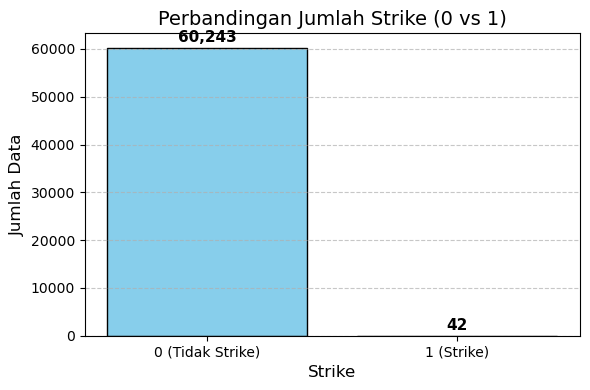

In [46]:
# Hitung jumlah strike 0 dan 1
strike_counts = df_model['strike'].value_counts().sort_index()

# Diagram batang
plt.figure(figsize=(6, 4))
bars = plt.bar(
    strike_counts.index.astype(str),
    strike_counts.values,
    color=['skyblue', 'salmon'],
    edgecolor='black'
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # posisi x di tengah batang
        height + (0.01 * max(strike_counts.values)),  # sedikit di atas batang
        f'{int(height):,}',  # format angka dengan koma ribuan
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
plt.title('Perbandingan Jumlah Strike (0 vs 1)', fontsize=14)
plt.xlabel('Strike', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)
plt.xticks([0, 1], ['0 (Tidak Strike)', '1 (Strike)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [47]:
def evaluate_model(y_test, y_pred, y_proba, name):
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],"--",color="red")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_prec = average_precision_score(y_test, y_proba)
    plt.figure(figsize=(6,6))
    plt.plot(recall, precision, label=f"AP = {avg_prec:.4f}", color="green")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.show()

    print(f"AUC: {roc_auc:.4f} | Average Precision: {avg_prec:.4f}")
    return roc_auc, avg_prec

##### <b> c. preprocessing

> weight

In [48]:
# class weights (for sklearn / keras)
from sklearn.utils import class_weight
from collections import Counter
print("Before resampling:", Counter(y_train))

classes = np.unique(y_train)
cw = class_weight.compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
print("class_weight_dict:", class_weight_dict)

Before resampling: Counter({0: 48194, 1: 34})
class_weight_dict: {0: 0.5003527410051044, 1: 709.2352941176471}


In [49]:
# scale_pos_weight for CatBoost/XGBoost: neg/pos
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0
print("scale_pos_weight (for CatBoost/XGBoost):", scale_pos_weight)

scale_pos_weight (for CatBoost/XGBoost): 1417.4705882352941


> convert

In [50]:
# SMOTE
from imblearn.over_sampling import SMOTE

X_train_float = X_train.copy()
for col in X_train_float.columns:
    if pd.api.types.is_bool_dtype(X_train_float[col]):
        X_train_float[col] = X_train_float[col].astype(int).astype(float)
    elif pd.api.types.is_integer_dtype(X_train_float[col]):
        X_train_float[col] = X_train_float[col].astype(float)
X_train_float = X_train_float.fillna(0).astype(float)

sm = SMOTE(random_state=42, n_jobs=-1)
X_train_smote_1, y_train_smote_1 = sm.fit_resample(X_train_float, y_train)
print("After SMOTE:", y_train_smote_1.value_counts())

scaler = StandardScaler()
X_train_scaled_1 = scaler.fit_transform(X_train_smote_1)
X_test_scaled_1 = scaler.transform(X_test)

After SMOTE: strike
0    48194
1    48194
Name: count, dtype: int64


c:\Users\nalin\anaconda3\Lib\site-packages\imblearn\over_sampling\_smote\base.py:336: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


In [51]:
# SMOTE part 2
# 0.2 artinya: setelah oversampling, jumlah minoritas = 20% dari mayoritas
sm = SMOTE(random_state=42, sampling_strategy=0.2)
X_train_smote, y_train_smote = sm.fit_resample(X_train_float, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print(y_train_smote.value_counts())

strike
0    48194
1     9638
Name: count, dtype: int64


In [52]:
# Random Undersampling (downsample majority)
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print("After RandomUnderSampler:", Counter(y_train_rus))

After RandomUnderSampler: Counter({0: 34, 1: 34})


In [53]:
# SMOTEENN (oversample + clean)
from imblearn.combine import SMOTEENN

X_train_float = X_train.copy()
for col in X_train_float.columns:
    if pd.api.types.is_bool_dtype(X_train_float[col]):
        X_train_float[col] = X_train_float[col].astype(int).astype(float)
    elif pd.api.types.is_integer_dtype(X_train_float[col]):
        X_train_float[col] = X_train_float[col].astype(float)
X_train_float = X_train_float.fillna(0).astype(float)

smote_enn = SMOTEENN(random_state=42)
X_train_smenn, y_train_smenn = smote_enn.fit_resample(X_train_float, y_train)

print("After SMOTEENN:", Counter(y_train_smenn))

After SMOTEENN: Counter({0: 47867, 1: 43619})


##### <b> d. model

###### <b> RF


=== Random Forest (balanced_subsample) ===
              precision    recall  f1-score   support

           0     0.9996    0.8524    0.9201     12049
           1     0.0022    0.5000    0.0045         8

    accuracy                         0.8521     12057
   macro avg     0.5009    0.6762    0.4623     12057
weighted avg     0.9989    0.8521    0.9195     12057



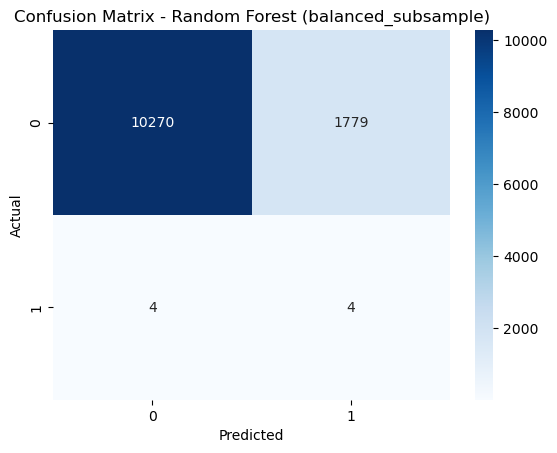

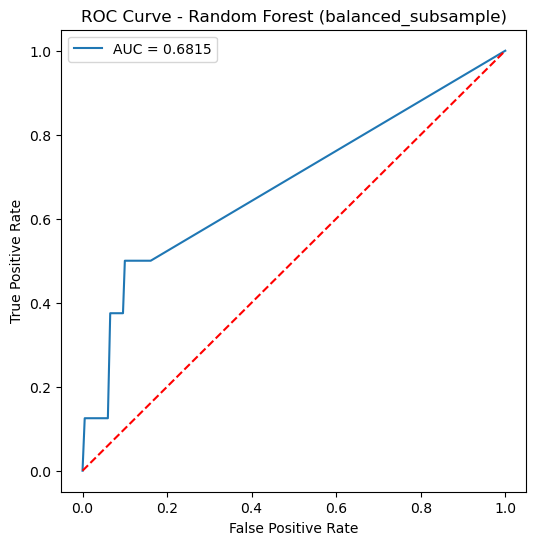

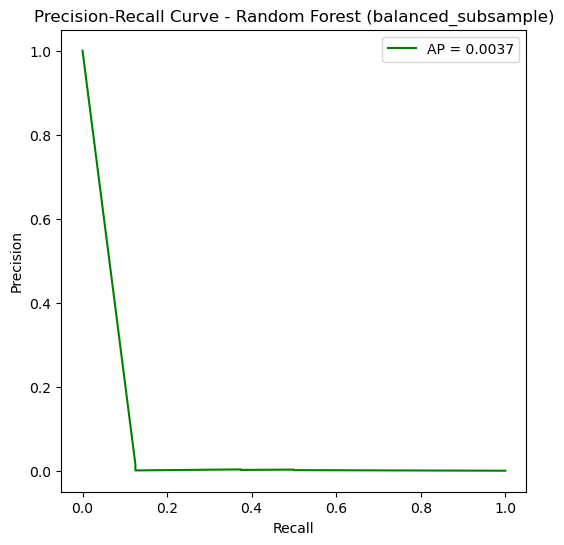

AUC: 0.6815 | Average Precision: 0.0037


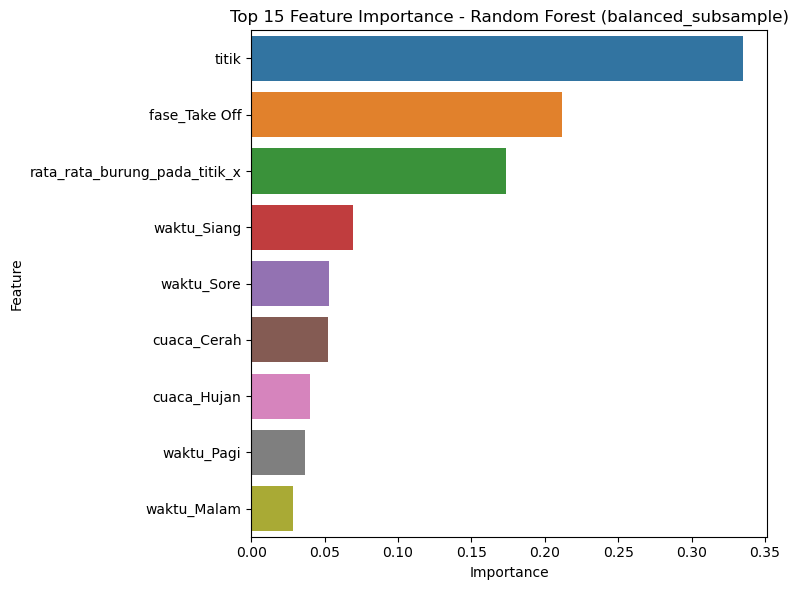

In [54]:
# v1
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "Random Forest (balanced_subsample)")

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importance - Random Forest (balanced_subsample)")
plt.tight_layout()
plt.show()



=== Random Forest (class_weight_dict) ===
              precision    recall  f1-score   support

           0     0.9996    0.8524    0.9201     12049
           1     0.0022    0.5000    0.0045         8

    accuracy                         0.8521     12057
   macro avg     0.5009    0.6762    0.4623     12057
weighted avg     0.9989    0.8521    0.9195     12057



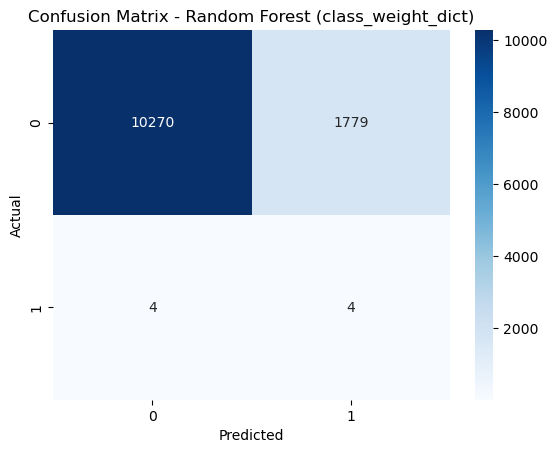

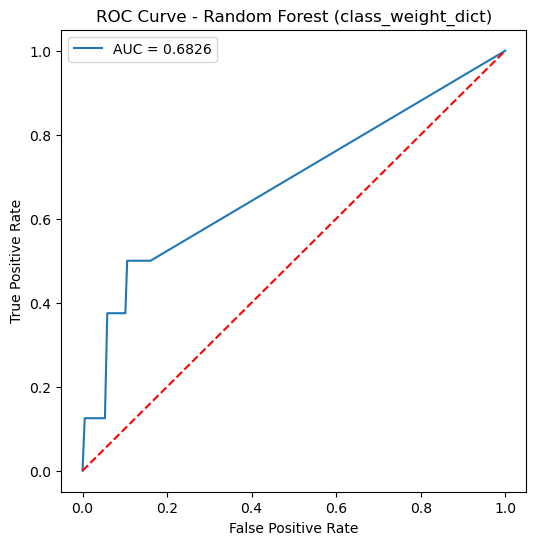

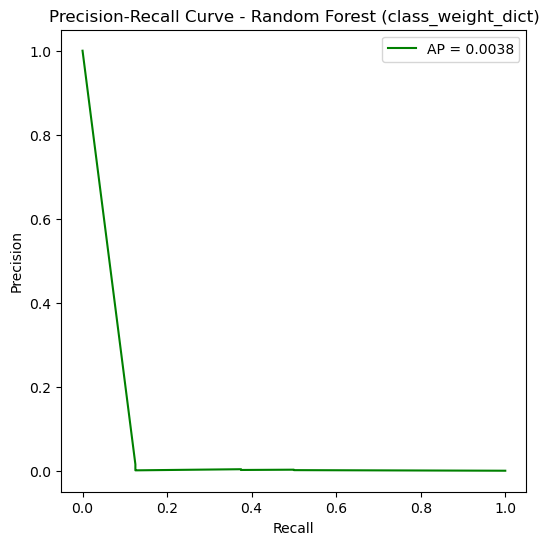

AUC: 0.6826 | Average Precision: 0.0038


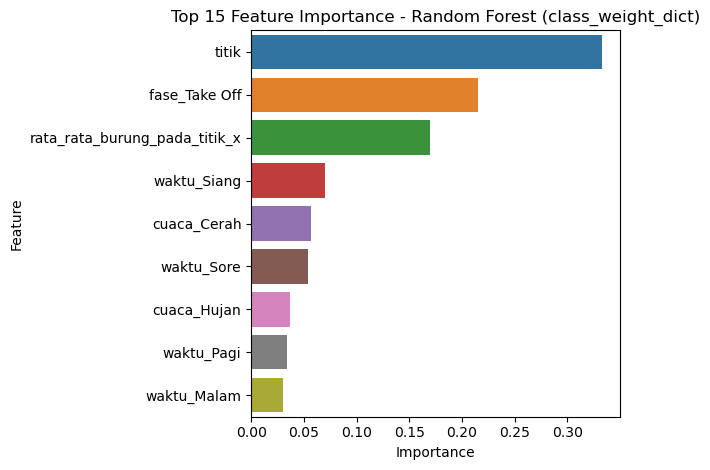

In [55]:
# v2
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=class_weight_dict,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "Random Forest (class_weight_dict)")

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importance - Random Forest (class_weight_dict)")
plt.tight_layout()
plt.show()


=== Random Forest (UnderSampled) ===
              precision    recall  f1-score   support

           0     0.9996    0.6246    0.7688     12049
           1     0.0011    0.6250    0.0022         8

    accuracy                         0.6246     12057
   macro avg     0.5004    0.6248    0.3855     12057
weighted avg     0.9989    0.6246    0.7683     12057



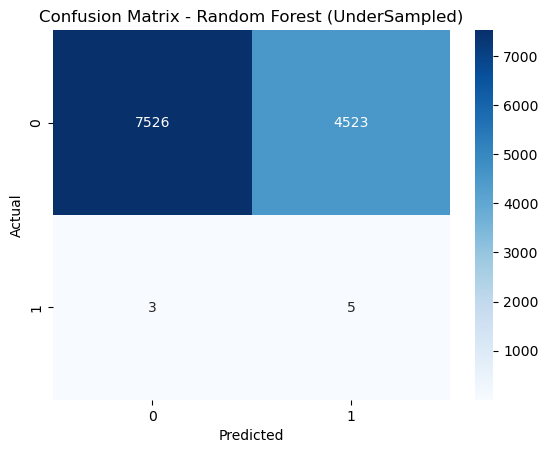

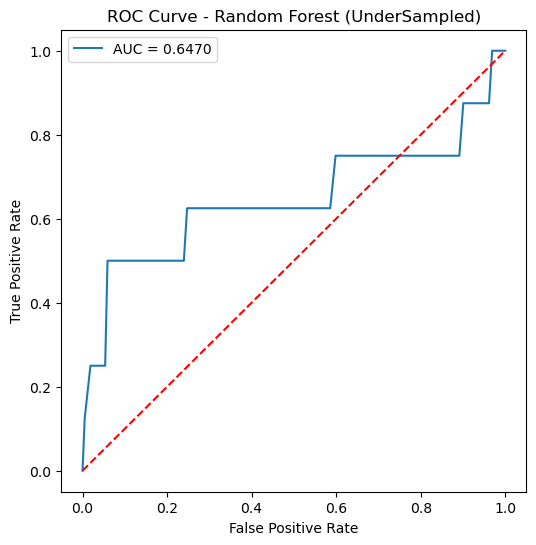

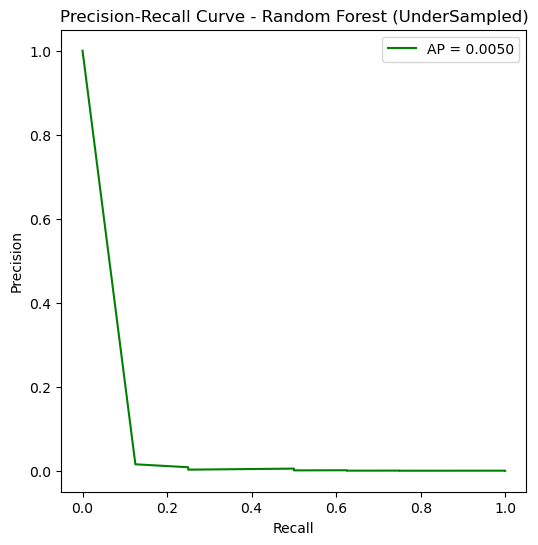

AUC: 0.6470 | Average Precision: 0.0050


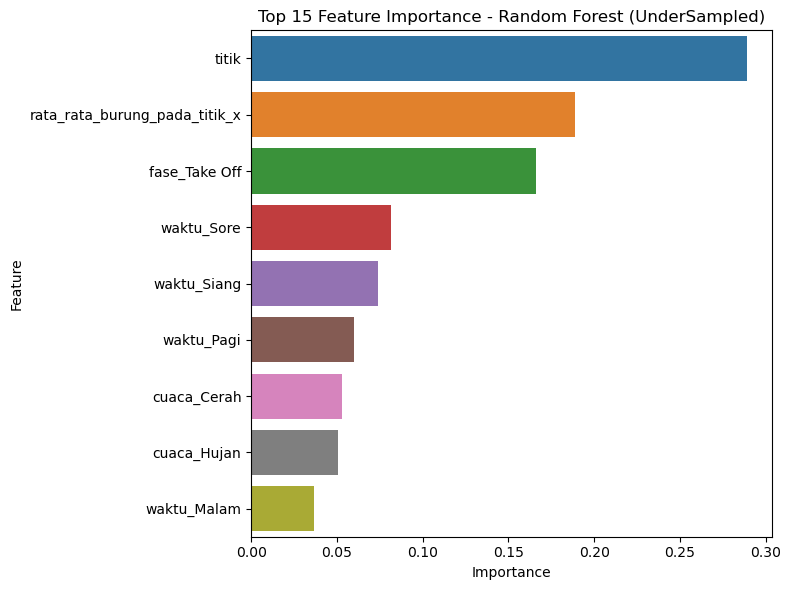

In [56]:
# v3
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_rus, y_train_rus)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "Random Forest (UnderSampled)")

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importance - Random Forest (UnderSampled)")
plt.tight_layout()
plt.show()


###### <b> CATBOOST


=== CatBoost ===
              precision    recall  f1-score   support

           0     0.9996    0.8401    0.9129     12049
           1     0.0021    0.5000    0.0041         8

    accuracy                         0.8398     12057
   macro avg     0.5008    0.6700    0.4585     12057
weighted avg     0.9989    0.8398    0.9123     12057



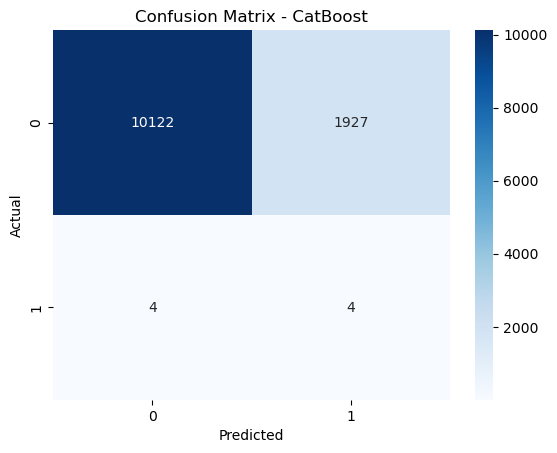

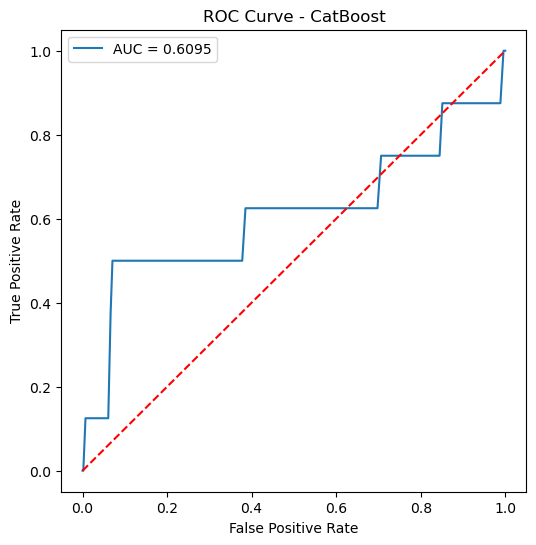

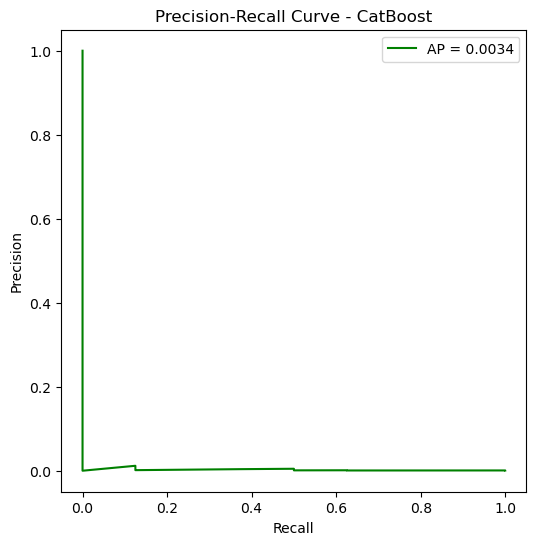

AUC: 0.6095 | Average Precision: 0.0034


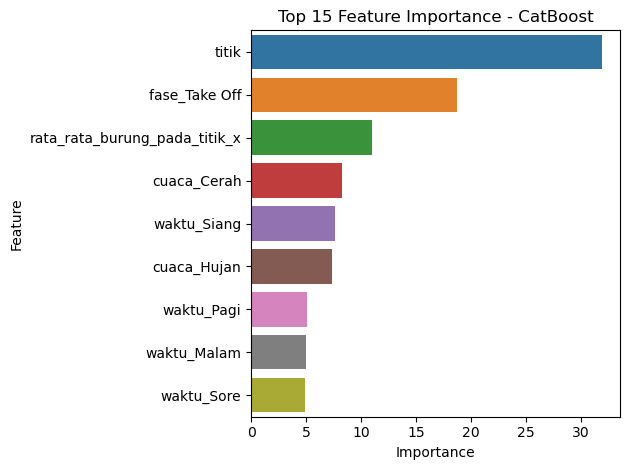

In [57]:
# v1
cat = CatBoostClassifier(
    verbose=0,
    random_state=42,
    class_weights=[1, 1000]
)
cat.fit(X_train, y_train)

y_pred = cat.predict(X_test)
y_proba = cat.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "CatBoost")

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importance - CatBoost")
plt.tight_layout()
plt.show()


0:	test: 0.6211563	best: 0.6211563 (0)	total: 14.1ms	remaining: 14.1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6583585775
bestIteration = 4

Shrink model to first 5 iterations.

=== CatBoost (Weighted) ===
              precision    recall  f1-score   support

           0     0.9997    0.7293    0.8433     12049
           1     0.0015    0.6250    0.0031         8

    accuracy                         0.7292     12057
   macro avg     0.5006    0.6771    0.4232     12057
weighted avg     0.9990    0.7292    0.8428     12057



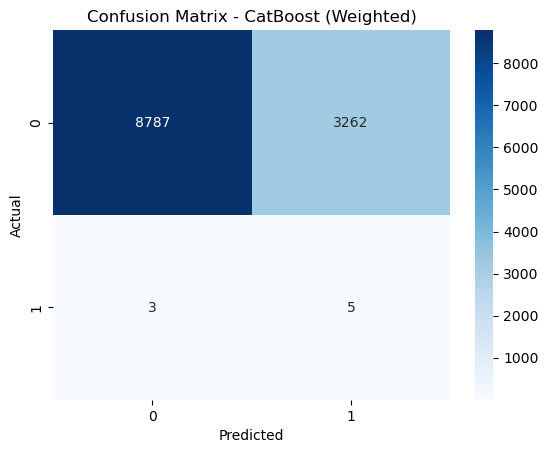

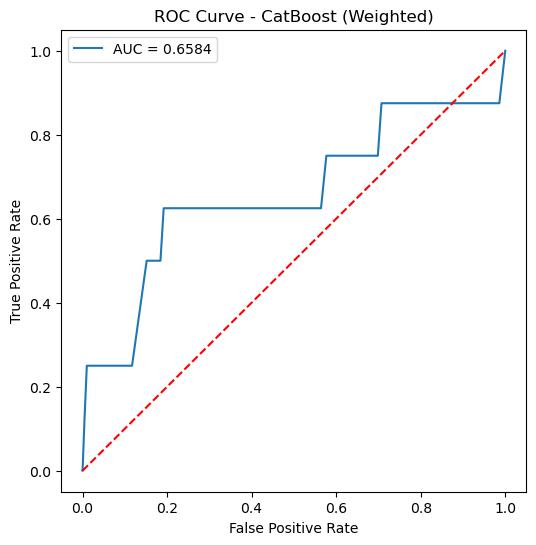

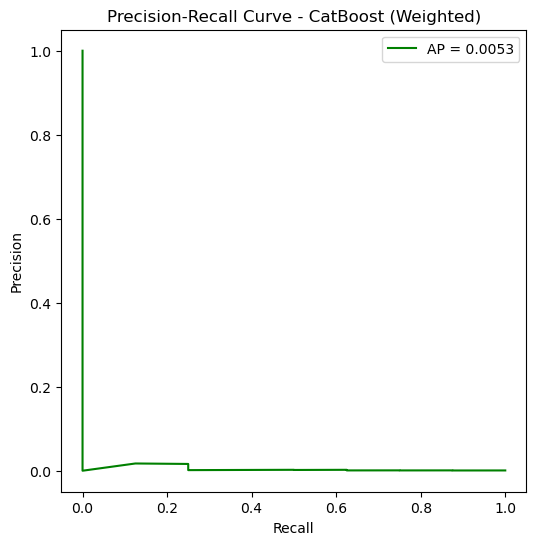

AUC: 0.6584 | Average Precision: 0.0053


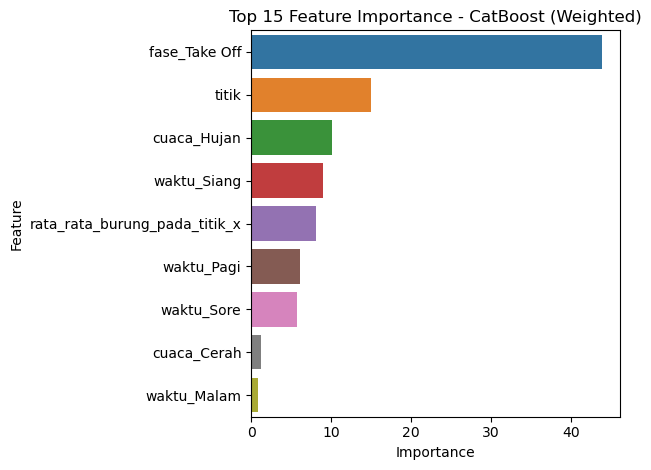

In [58]:
# v2
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    scale_pos_weight=scale_pos_weight
)

cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100)

y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "CatBoost (Weighted)")

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importance - CatBoost (Weighted)")
plt.tight_layout()
plt.show()

###### <b> LR


=== Logistic Regression (SMOTEENN) ===
              precision    recall  f1-score   support

           0     0.9993    0.2507    0.4009     12049
           1     0.0007    0.7500    0.0013         8

    accuracy                         0.2511     12057
   macro avg     0.5000    0.5004    0.2011     12057
weighted avg     0.9987    0.2511    0.4006     12057



c:\Users\nalin\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\nalin\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


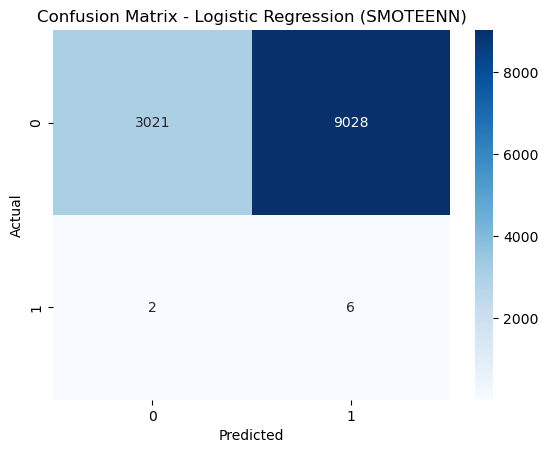

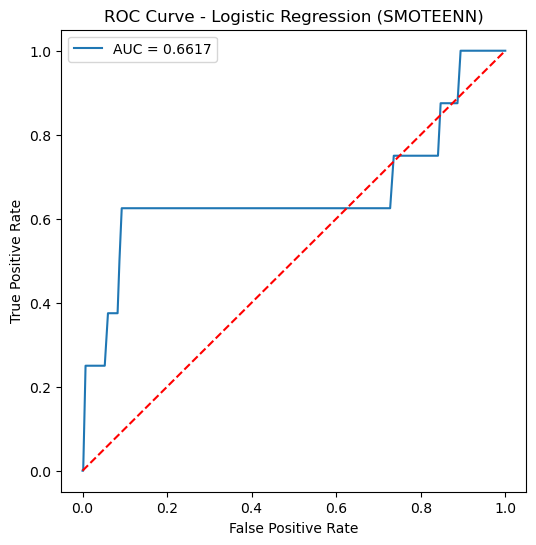

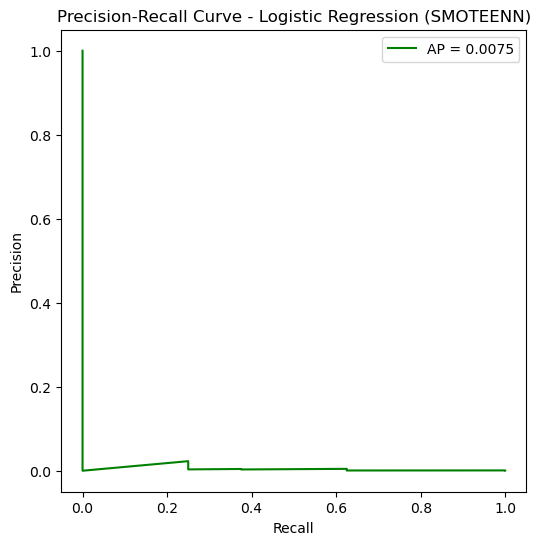

AUC: 0.6617 | Average Precision: 0.0075


(0.6616679807452901, 0.0074918320310988955)

In [59]:
# v1
X_train_use, X_test_use, y_train_use = X_train_smenn, X_test_scaled, y_train_smenn

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

logreg.fit(X_train_use, y_train_use)
y_pred = logreg.predict(X_test_use)
y_proba = logreg.predict_proba(X_test_use)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "Logistic Regression (SMOTEENN)")


=== Logistic Regression (UnderSampled) ===
              precision    recall  f1-score   support

           0     0.9996    0.5754    0.7304     12049
           1     0.0010    0.6250    0.0019         8

    accuracy                         0.5754     12057
   macro avg     0.5003    0.6002    0.3662     12057
weighted avg     0.9989    0.5754    0.7299     12057



c:\Users\nalin\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\nalin\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


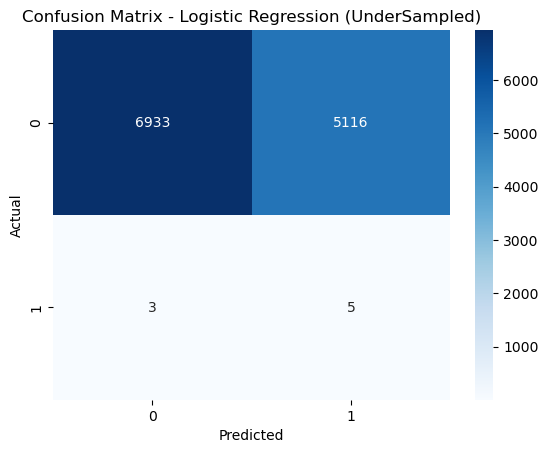

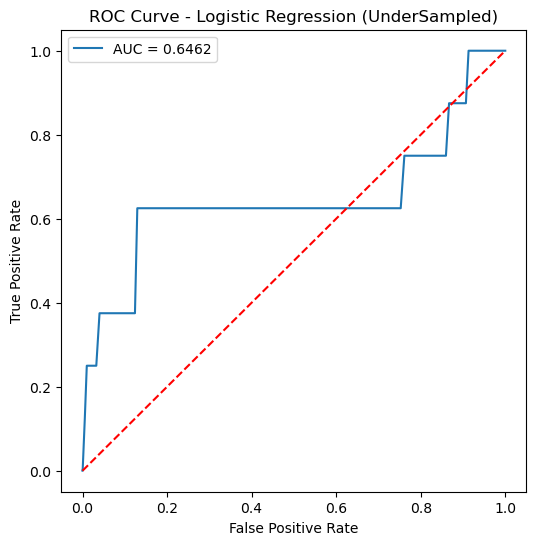

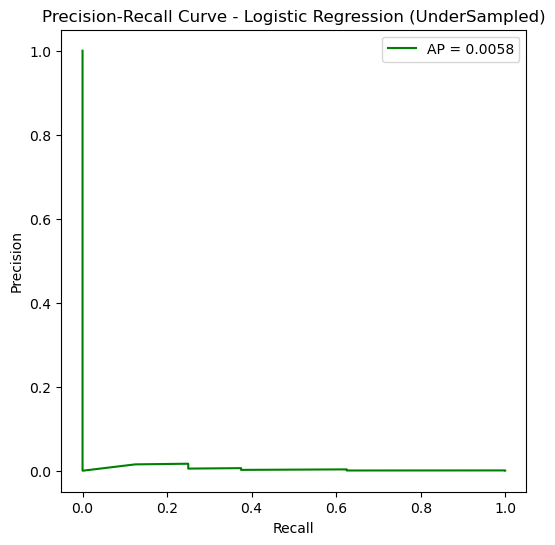

AUC: 0.6462 | Average Precision: 0.0058


(0.6461687691924641, 0.005801740707735893)

In [60]:
# v2
X_train_use, X_test_use, y_train_use = X_train_rus, X_test_scaled, y_train_rus

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

logreg.fit(X_train_use, y_train_use)
y_pred = logreg.predict(X_test_use)
y_proba = logreg.predict_proba(X_test_use)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "Logistic Regression (UnderSampled)")


=== Logistic Regression (SMOTE) ===
              precision    recall  f1-score   support

           0     0.9996    0.6433    0.7828     12049
           1     0.0012    0.6250    0.0023         8

    accuracy                         0.6433     12057
   macro avg     0.5004    0.6341    0.3926     12057
weighted avg     0.9990    0.6433    0.7823     12057



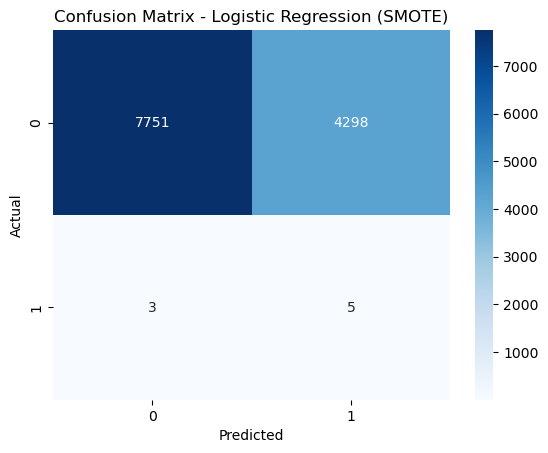

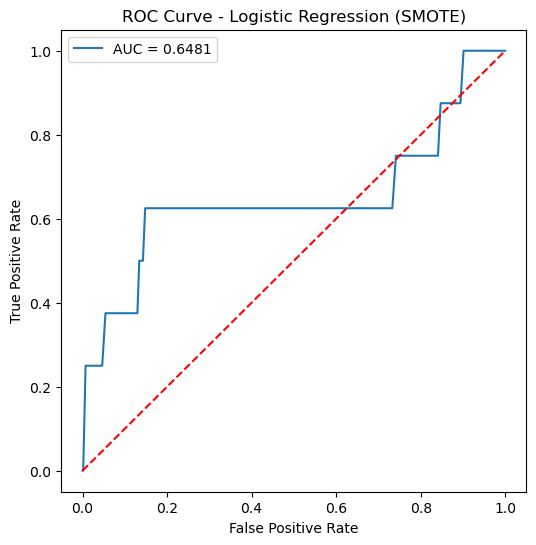

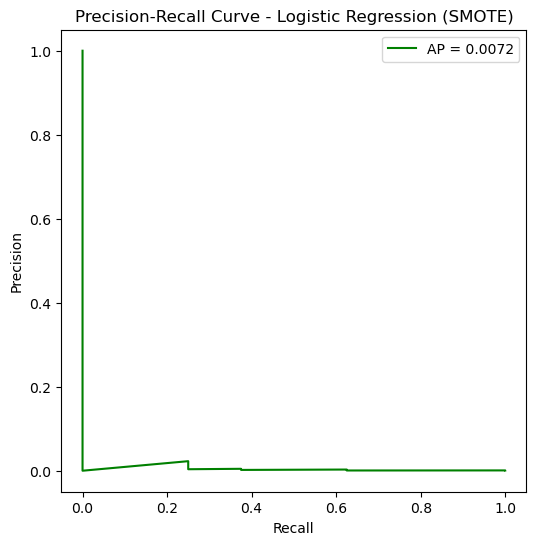

AUC: 0.6481 | Average Precision: 0.0072


(0.6480983899078762, 0.007173050653397224)

In [61]:
# v3
X_train_use, X_test_use, y_train_use = X_train_scaled_1, X_test_scaled_1, y_train_smote_1


logreg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

logreg.fit(X_train_use, y_train_use)
y_pred = logreg.predict(X_test_use)
y_proba = logreg.predict_proba(X_test_use)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "Logistic Regression (SMOTE)")



=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.9996    0.6433    0.7828     12049
           1     0.0012    0.6250    0.0023         8

    accuracy                         0.6433     12057
   macro avg     0.5004    0.6341    0.3926     12057
weighted avg     0.9990    0.6433    0.7823     12057



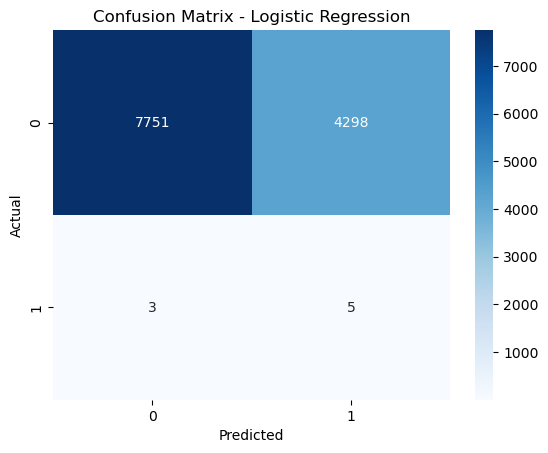

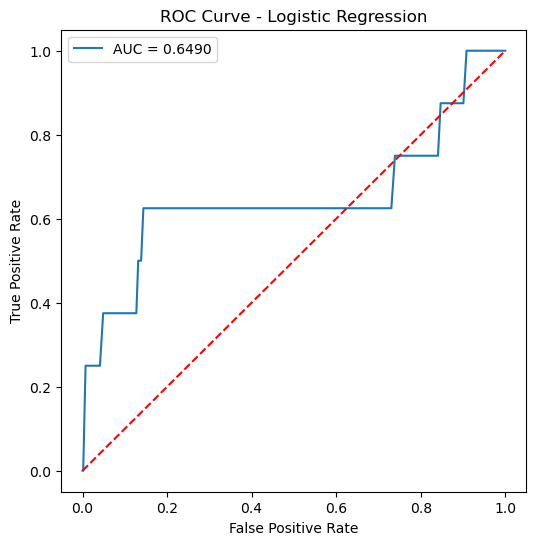

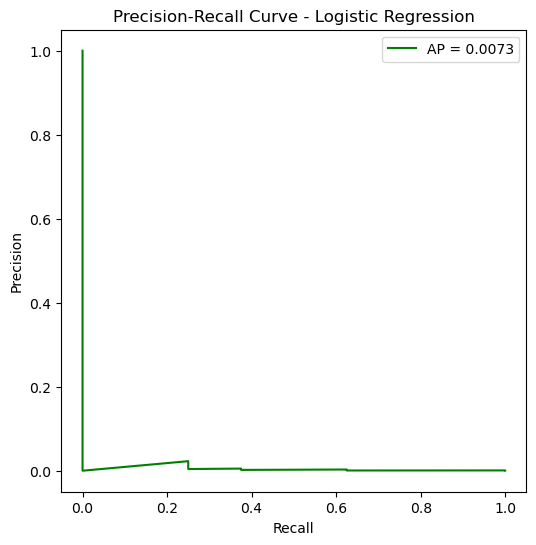

AUC: 0.6490 | Average Precision: 0.0073


(0.6490217030458959, 0.0072515510361167365)

In [62]:
X_train_use, X_test_use, y_train_use = X_train_scaled, X_test_scaled, y_train_smote

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"  # tetap bisa override class imbalance ringan
)

logreg.fit(X_train_use, y_train_use)
y_pred = logreg.predict(X_test_use)
y_proba = logreg.predict_proba(X_test_use)[:, 1]

evaluate_model(y_test, y_pred, y_proba, "Logistic Regression")

###### <b> SVM [Best]


=== SVM RBF (subset-trained) ===
              precision    recall  f1-score   support

           0     0.9996    0.9027    0.9487     12049
           1     0.0034    0.5000    0.0068         8

    accuracy                         0.9025     12057
   macro avg     0.5015    0.7014    0.4777     12057
weighted avg     0.9990    0.9025    0.9481     12057



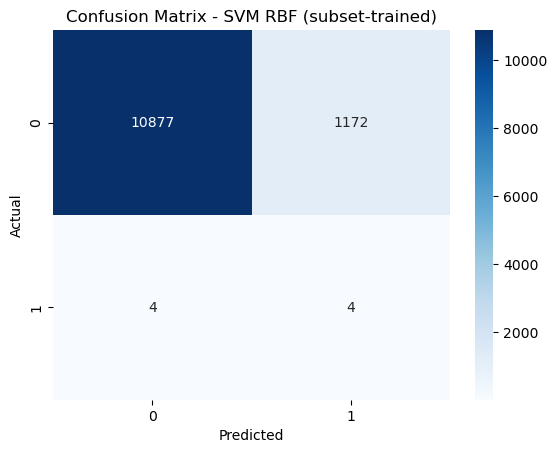

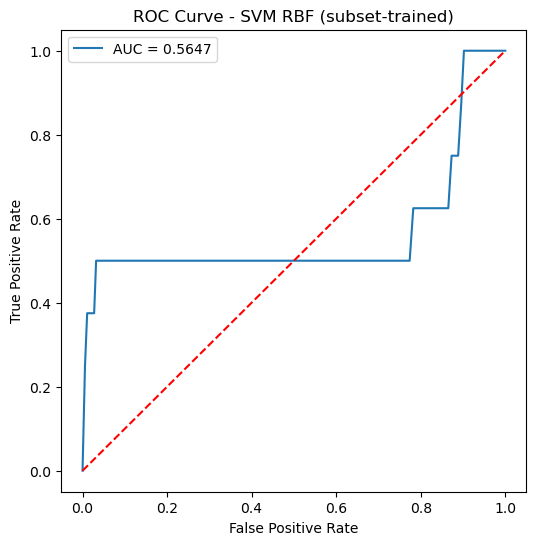

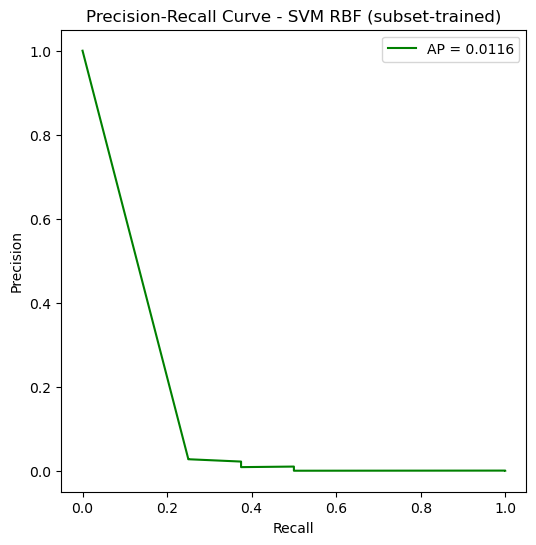

AUC: 0.5647 | Average Precision: 0.0116


(0.5647408498630592, 0.011623274347997216)

In [83]:
X_sub, y_sub = resample(X_train_scaled, y_train_smote, n_samples=20000, random_state=42)

svm = SVC(probability=True, class_weight="balanced", kernel="rbf", random_state=42)
svm.fit(X_sub, y_sub)
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]
evaluate_model(y_test, y_pred, y_proba, "SVM RBF (subset-trained)")
